# Bibliotekos

In [158]:
import pandas as pd
import numpy as np
import torch
torch.cuda.is_available()
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr
from skorch import NeuralNetRegressor
from skorch.callbacks import Checkpoint, EarlyStopping
from skorch.dataset import ValidSplit

import importlib
import Lasso2
importlib.reload(Lasso2)
from Lasso2 import select_features_lasso

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV

from sklearn.base import BaseEstimator, RegressorMixin
from skorch import NeuralNetRegressor

from sklearn.metrics import make_scorer, root_mean_squared_error

import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
torch.use_deterministic_algorithms(True)

# Duomenų paruošimas

In [159]:
data = pd.read_csv("../datasets_prep/dm_project_dataset.csv")

data['observationTime'] = pd.to_datetime(data['observationTime'])
data['month'] = data['observationTime'].dt.month
data['day_of_year'] = data['observationTime'].dt.dayofyear
data['day_of_week'] = data['observationTime'].dt.dayofweek

data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)

lag_config = {
    'absorbing_aerosol_index': [8],
    'H2O_column_number_density': [1],
    'NO2_column_number_density': [1, 2],
    'stratospheric_NO2_column_number_density': [1, 3, 7],
    'NO2_slant_column_number_density': [1, 2],
    'tropopause_pressure': [1],
    'nmvoc': [1, 2],
    'nh3': [1, 11],
    'pm10': [1, 11],
    'sia': [11],
    'pans': [10],
    'dust': [1, 4],
    'pm2p5': [1, 11],
    'NO2': [1, 4, 9],

    # METEO
    'airTemperature': [1, 3, 9, 10],
    'seaLevelPressure': [1, 2],
    'relativeHumidity': [1, 2],
    'xgb_cloudCover': [1, 2],
    'windSpeed_fixed': [1, 2, 3],
    'windGust_fixed': [1, 2],
    'windDirection_fixed': [4, 10]
}

for feature, lags in lag_config.items():
    for lag in lags:
        data[f'{feature}_lag{lag}'] = data[feature].shift(lag)

# data['target'] = data['missforest_precipitation'].shift(-1)
data = data.dropna()
observation_times = data['observationTime'].copy()

drop_names = [
    'observationTime',
]

# X = data.drop(columns=drop_names)
X = data
# y = data['target']

In [160]:
X.head()

,observationTime,absorbing_aerosol_index,NO2_column_number_density,stratospheric_NO2_column_number_density,NO2_slant_column_number_density,tropopause_pressure,H2O_column_number_density,BrO,BrO_Error,NO2,...,relativeHumidity_lag2,xgb_cloudCover_lag1,xgb_cloudCover_lag2,windSpeed_fixed_lag1,windSpeed_fixed_lag2,windSpeed_fixed_lag3,windGust_fixed_lag1,windGust_fixed_lag2,windDirection_fixed_lag4,windDirection_fixed_lag10
11,2018-07-12,-1.259574,0.000091,0.000061,0.000205,19223.746,2092.265400,1.413290e+13,1.937367e+13,3.779792e+15,...,72.416667,53.916667,65.916667,0.879167,0.891667,2.462500,8.7,6.2,315.0,327.0
12,2018-07-13,-1.214123,0.000084,0.000065,0.000208,19219.334,2178.943600,3.610126e+13,1.652258e+13,3.688520e+15,...,79.083333,46.541667,53.916667,1.495833,0.879167,0.891667,10.8,8.7,294.0,271.0
13,2018-07-14,-0.762476,0.000079,0.000063,0.000203,19222.883,2346.339133,3.659979e+13,1.520030e+13,4.186392e+15,...,76.166667,82.583333,46.541667,1.270833,1.495833,0.879167,8.0,10.8,5.0,288.0
14,2018-07-15,-1.098520,0.000090,0.000057,0.000149,16677.404,2322.217746,3.449885e+13,1.453966e+13,3.940498e+15,...,84.541667,83.478261,82.583333,0.645833,1.270833,1.495833,6.6,8.0,2.0,293.0
15,2018-07-16,-0.770874,0.000077,0.000062,0.000183,16673.053,2747.987500,3.512158e+13,1.647380e+13,3.581072e+15,...,87.625000,69.708333,83.478261,1.270833,0.645833,1.270833,6.1,6.6,127.0,275.0


# SSA

In [161]:
# ── LeakFreeSSA: fits eigenvectors on train only ────────────────────────────

class LeakFreeSSA:
    """
    Singular Spectrum Analysis with strict separation of fit and transform.

    fit(train_series)
        Builds trajectory matrix from train only, computes eigenvectors U_.

    transform_train(train_series)
        Reconstructs all components for the training series.

    transform_test(train_series, test_series)
        For each test point, reconstructs using [train + test_so_far] context
        but projects onto the TRAIN eigenvectors only.
        Returns components of shape (n_components, len(test_series)).
    """

    def __init__(self, window_size: int = 10, n_components: int = 10):
        self.L = window_size
        self.n_components = n_components

    def _trajectory_matrix(self, series: np.ndarray) -> np.ndarray:
        """Build the (L × K) Hankel trajectory matrix."""
        K = len(series) - self.L + 1
        return np.array([series[i: i + self.L] for i in range(K)]).T  # (L, K)

    def fit(self, series: np.ndarray):
        """Compute and store eigenvectors from train series."""
        X = self._trajectory_matrix(series)          # (L, K)
        S = X @ X.T                                  # (L, L)
        eigenvalues, eigenvectors = np.linalg.eigh(S)
        idx = np.argsort(eigenvalues)[::-1]
        self.eigenvalues_ = eigenvalues[idx]
        self.U_ = eigenvectors[:, idx][:, :self.n_components]  # (L, n_comp)
        return self

    def _reconstruct(self, series: np.ndarray) -> np.ndarray:
        """Project series onto stored eigenvectors and diagonal-average back."""
        N = len(series)
        K = N - self.L + 1
        X = self._trajectory_matrix(series)          # (L, K)
        components = np.zeros((self.n_components, N))
        for i in range(self.n_components):
            u  = self.U_[:, i]                       # (L,)
            v  = u @ X                               # (K,)
            Xi = np.outer(u, v)                      # (L, K)
            comp  = np.zeros(N)
            count = np.zeros(N)
            for col in range(K):
                for row in range(self.L):
                    t = row + col
                    comp[t]  += Xi[row, col]
                    count[t] += 1
            components[i] = comp / count
        return components

    def transform_train(self, series: np.ndarray) -> np.ndarray:
        return self._reconstruct(series)

    def transform_test(self, train_series, test_series):
        N_test = len(test_series)
        result = np.zeros((self.n_components, N_test))
        
        for t in range(N_test):
            # Only use train + test up to and including day t
            context = np.concatenate([train_series, test_series[:t+1]])
            comps = self._reconstruct(context)
            # Take only the last value (today's reconstruction)
            result[:, t] = comps[:, -1]
        
        return result


# ── Exploratory SSA on the train series only (for visualisation) ─────────────
series_full_log = np.log1p(data['missforest_precipitation'].values)

L      = 10
N_COMP = 10

split_idx_explore = int(len(data) * 0.9)
train_series_explore = series_full_log[:split_idx_explore]

ssa_explore = LeakFreeSSA(window_size=L, n_components=N_COMP)
ssa_explore.fit(train_series_explore)
components = ssa_explore.transform_train(train_series_explore)

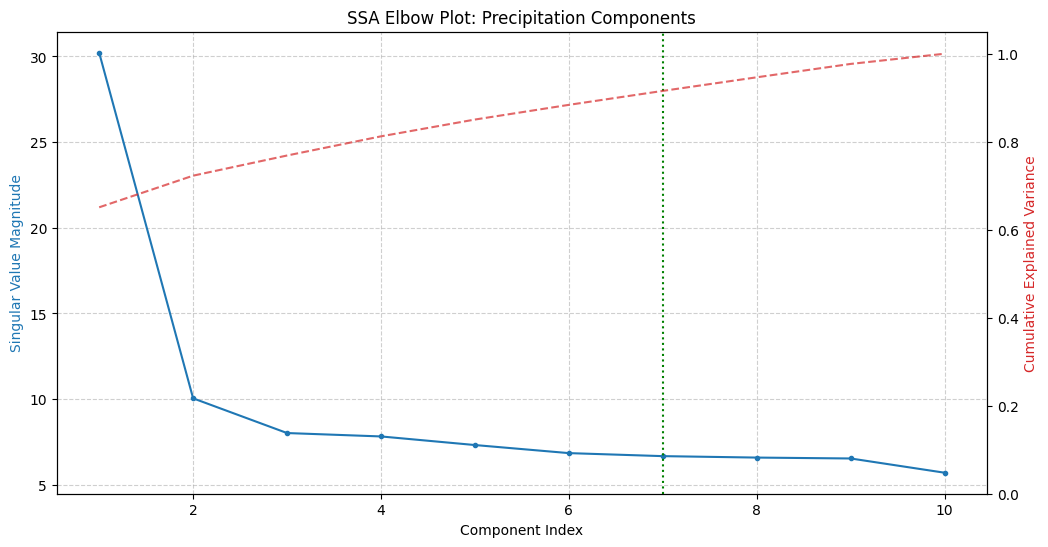

In [162]:
component_energies = np.array([np.sum(c**2) for c in components])
singular_values = np.sqrt(component_energies)

# 2. Sort them (SSA components are usually already sorted)
idx = np.argsort(singular_values)[::-1]
singular_values = singular_values[idx]

# 3. Calculate Variance Explained
total_var = np.sum(singular_values**2)
explained_variance = (singular_values**2) / total_var
cumulative_variance = np.cumsum(explained_variance)

# --- PLOTTING ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Singular Values (The Elbow)
ax1.plot(range(1, L + 1), singular_values, marker='o', markersize=3, color='tab:blue', label='Singular Values')
ax1.set_xlabel('Component Index')
ax1.set_ylabel('Singular Value Magnitude', color='tab:blue')
ax1.set_title('SSA Elbow Plot: Precipitation Components')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot Cumulative Variance (To see how much info you keep)
ax2 = ax1.twinx()
ax2.plot(range(1, L + 1), cumulative_variance, color='tab:red', linestyle='--', alpha=0.7, label='Cumulative Variance')
ax2.set_ylabel('Cumulative Explained Variance', color='tab:red')
ax2.set_ylim(0, 1.05)

# Add a vertical line at a suggested cutoff (e.g., where 90% variance is reached)
cutoff_90 = np.where(cumulative_variance >= 0.90)[0][0] + 1
ax1.axvline(x=cutoff_90, color='green', linestyle=':', label=f'90% Var ({cutoff_90} comps)')

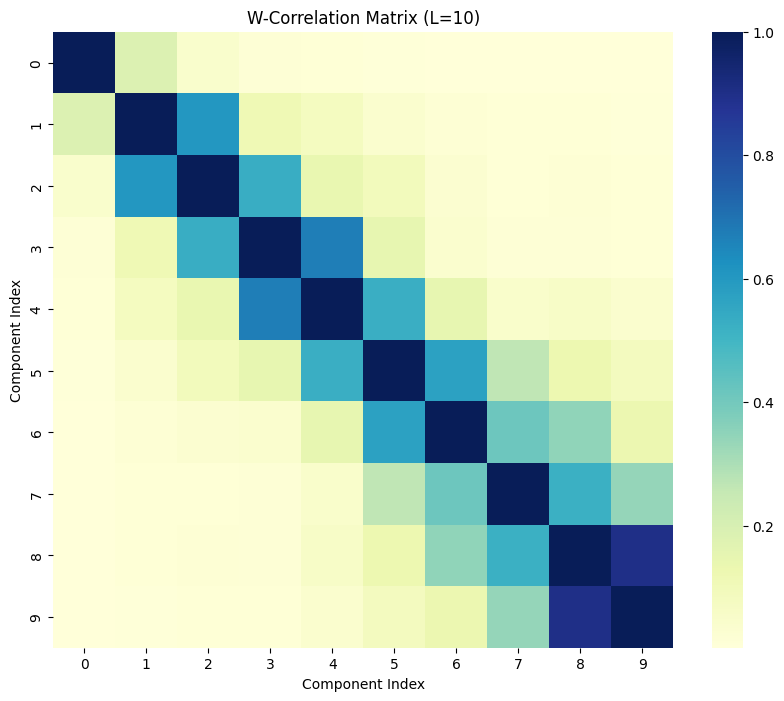

In [163]:
def plot_w_correlation(components):
    L, N = components.shape
    # Define the weights (w_i)
    # This reflects how many times each observation was used in the trajectory matrix
    K = N - L + 1
    w = np.array([min(i + 1, L, N - i) for i in range(N)])
    
    w_corr = np.zeros((L, L))
    
    # Calculate weighted norms once for efficiency
    weighted_norms = [np.sqrt(np.sum(w * (c**2))) for c in components]
    
    for i in range(L):
        for j in range(i, L):
            numerator = np.sum(w * components[i] * components[j])
            denominator = weighted_norms[i] * weighted_norms[j]
            val = abs(numerator / denominator)
            w_corr[i, j] = val
            w_corr[j, i] = val # Matrix is symmetric
            
    # Plotting
    plt.figure(figsize=(10, 8))
    sns.heatmap(w_corr, cmap='YlGnBu', annot=False)
    plt.title(f'W-Correlation Matrix (L={L})')
    plt.xlabel('Component Index')
    plt.ylabel('Component Index')
    plt.show()
    
    return w_corr

# Use it on your first 20-30 components (plotting 365 is too dense to read)
w_matrix = plot_w_correlation(components[:120])

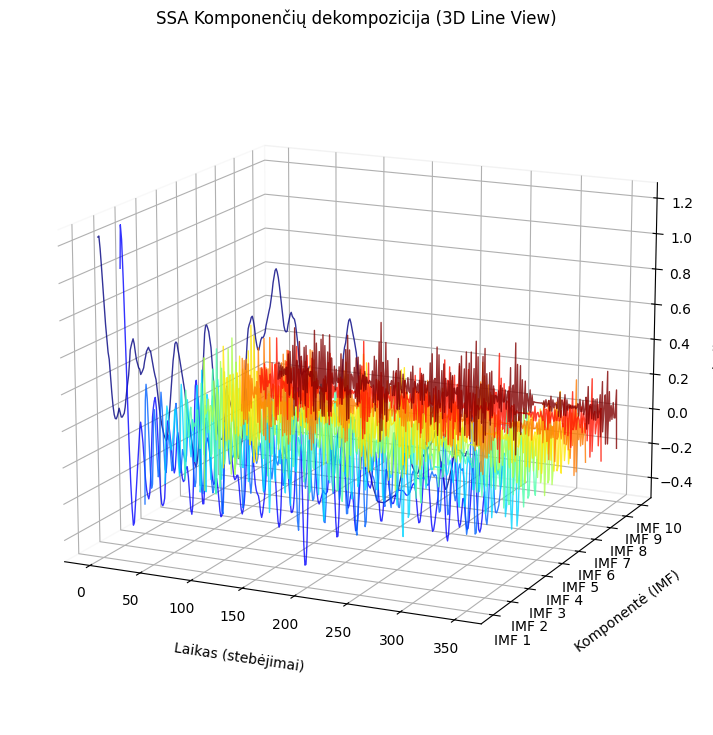

In [164]:
fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')
# Nustatome segmentą vizualizacijai (pvz., pirmos 1500 valandų)
n_points = min(350, len(train_series_explore))
x = np.arange(n_points)
zs = np.arange(N_COMP)

# Spalvų paletė
colors = plt.cm.jet(np.linspace(0, 1, N_COMP))

for i in range(N_COMP):
    y = components[i][:n_points]
    ax.plot(x, [i] * n_points, y, color=colors[i], linewidth=1, alpha=0.8)

ax.set_xlabel('Laikas (stebėjimai)', labelpad=15)
ax.set_ylabel('Komponentė (IMF)', labelpad=15)
ax.set_zlabel('Krituliai (mm)', labelpad=10)

ax.view_init(elev=15, azim=-65)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

ax.set_yticks(zs)
ax.set_yticklabels([f'IMF {i+1}' for i in zs])

plt.title("SSA Komponenčių dekompozicija (3D Line View)")
plt.show()

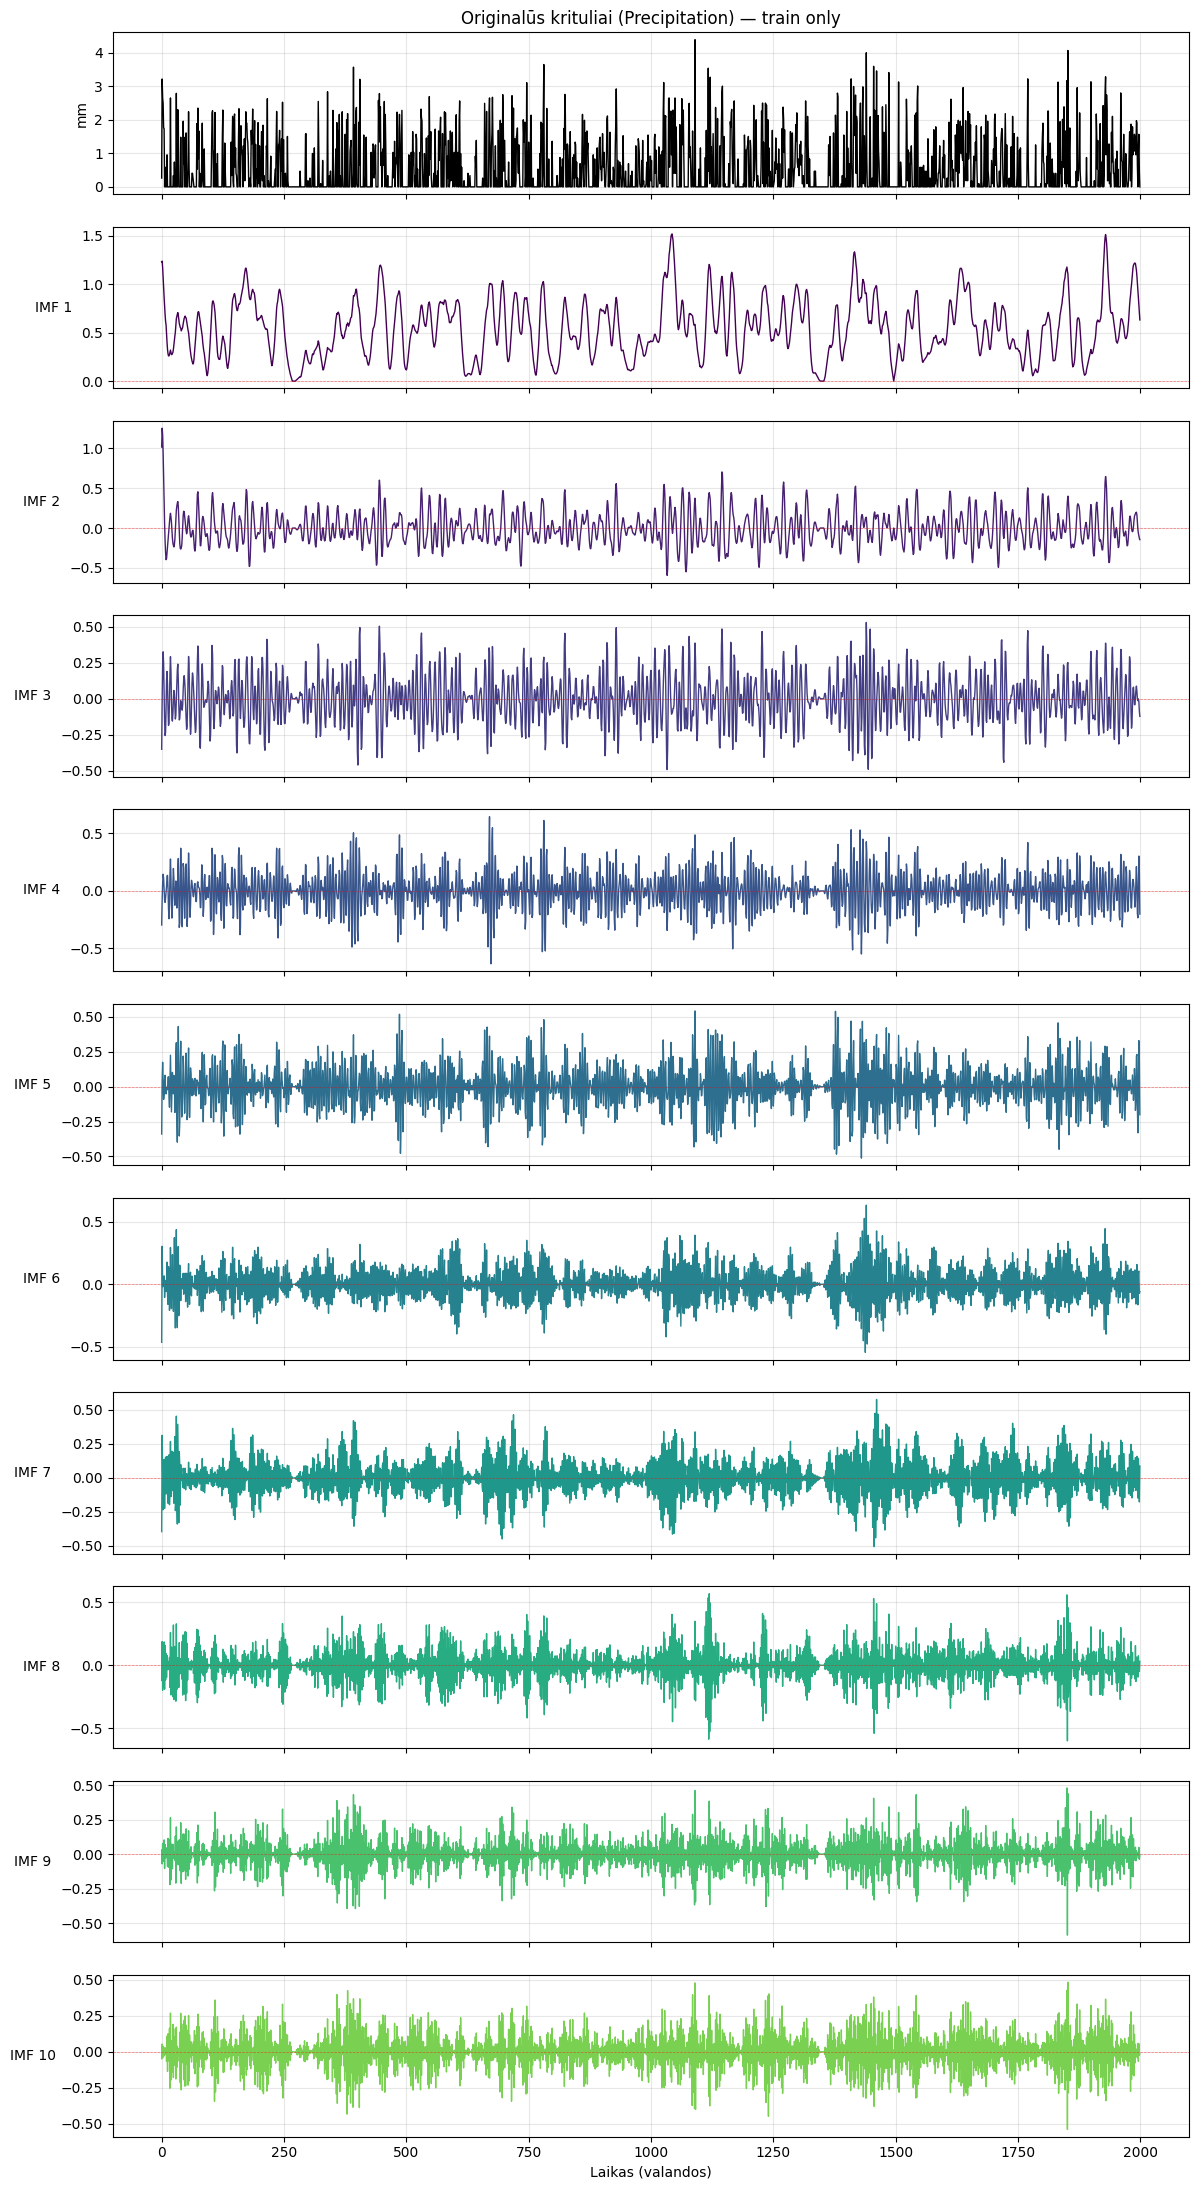

In [165]:
N = 10

fig, axes = plt.subplots(N + 1, 1, figsize=(12, 2 * (N + 1)), sharex=True)

n_points = min(2000, len(train_series_explore))
time_axis = np.arange(n_points)

# Viršutinis grafikas - Originalūs duomenys
axes[0].plot(time_axis, train_series_explore[:n_points], color='black', linewidth=1)
axes[0].set_title('Originalūs krituliai (Precipitation) — train only', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylabel('mm')

colors = plt.cm.viridis(np.linspace(0, 0.8, N))

for i in range(N):
    ax = axes[i + 1]
    ax.plot(time_axis, components[i][:n_points], color=colors[i], linewidth=1)
    ax.set_ylabel(f'IMF {i+1}', rotation=0, labelpad=20, verticalalignment='center')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='red', linestyle='--', linewidth=0.5, alpha=0.5)

axes[-1].set_xlabel('Laikas (valandos)')
plt.tight_layout()
plt.subplots_adjust(hspace=0.2)
plt.show()

In [166]:
how_group = {
    '1': [0],
    '2': [1],
    '3': [2],
    '4': [3],
    '5': [4],
    '6': [5],
    '7': [6],
    '8': [7, 8, 9],
}

# how_group = {
#     '1': [0],
#     '2': [1],
#     '3': [2],
#     '4': [3, 4],
#     '5': [5],
#     '6': [6, 7, 8, 9],
#     '7': [10, 11, 12],
#     '8': np.arange(13, 120, 1)
# }

# Build grouped components for the EXPLORATORY visualisation (train only)
grouped = []
for key in how_group:
    new_comp = np.zeros_like(components[0])
    for idx in how_group[key]:
        new_comp += components[idx]
    grouped.append(new_comp)

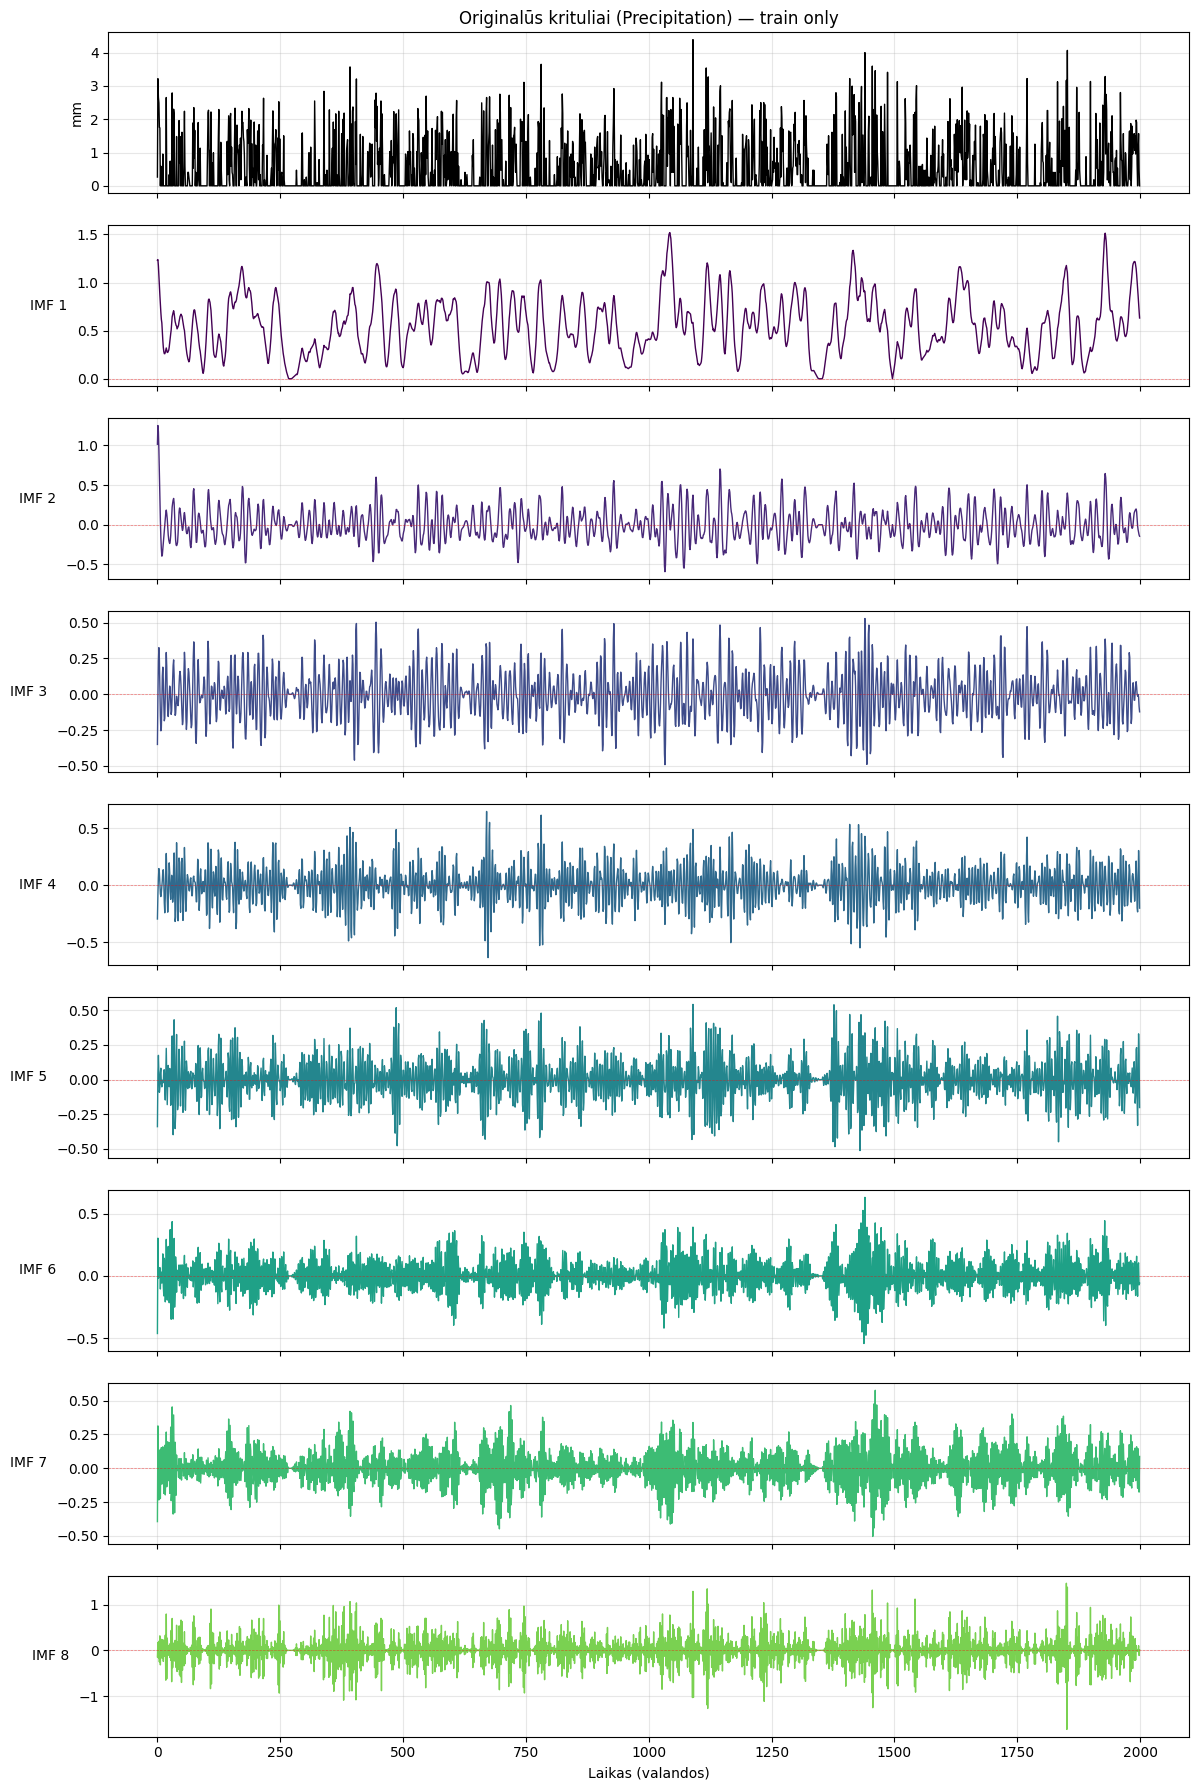

In [167]:
N = 8

fig, axes = plt.subplots(N + 1, 1, figsize=(12, 2 * (N + 1)), sharex=True)

n_points = min(2000, len(train_series_explore))
time_axis = np.arange(n_points)

# Viršutinis grafikas - Originalūs duomenys
axes[0].plot(time_axis, train_series_explore[:n_points], color='black', linewidth=1)
axes[0].set_title('Originalūs krituliai (Precipitation) — train only', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylabel('mm')

colors = plt.cm.viridis(np.linspace(0, 0.8, N))

for i in range(N):
    ax = axes[i + 1]
    ax.plot(time_axis, grouped[i][:n_points], color=colors[i], linewidth=1)
    ax.set_ylabel(f'IMF {i+1}', rotation=0, labelpad=20, verticalalignment='center')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='red', linestyle='--', linewidth=0.5, alpha=0.5)

axes[-1].set_xlabel('Laikas (valandos)')
plt.tight_layout()
plt.subplots_adjust(hspace=0.2)
plt.show()

# SSA Mokymo testavimo aibės — leakage-free

## Skirstymas

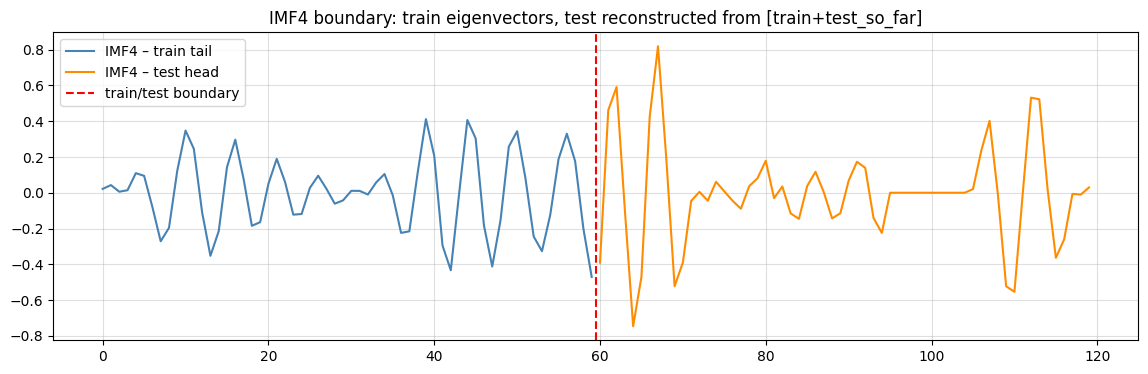

In [168]:
# ── 1. Split BEFORE any SSA ──────────────────────────────────────────────────
split_idx = int(len(X) * 0.8)
# split_idx = 2017

X_train_raw = X.iloc[:split_idx].copy()
X_test_raw  = X.iloc[split_idx:].copy()

# ── 2. Log-transform target series ───────────────────────────────────────────
train_series = np.log1p(X_train_raw['missforest_precipitation'].values)
test_series  = np.log1p(X_test_raw['missforest_precipitation'].values)

# ── 3. Fit SSA on TRAIN only ──────────────────────────────────────────────────
ssa = LeakFreeSSA(window_size=L, n_components=N_COMP)
ssa.fit(train_series)

# ── 4. Reconstruct components ─────────────────────────────────────────────────
#   Train: eigenvectors were fitted here — fully leak-free
#   Test : prepend full train for boundary context, project on TRAIN eigenvectors,
#          slice off only the test portion → no future values involved
train_components = ssa.transform_train(train_series)          # (N_COMP, N_train)
test_components  = ssa.transform_test(train_series,           # (N_COMP, N_test)
                                      test_series)

# ── 5. Group components into IMFs ─────────────────────────────────────────────
def make_grouped(components):
    grouped = []
    for key in how_group:
        new_comp = np.zeros(components.shape[1])
        for idx in how_group[key]:
            new_comp += components[idx]
        grouped.append(new_comp)
    return grouped

train_grouped = make_grouped(train_components)
test_grouped  = make_grouped(test_components)

# ── 6. Assign IMF columns back into the split DataFrames ─────────────────────
for i, key in enumerate(how_group):
    X_train_raw[f'IMF{i+1}'] = train_grouped[i]
    X_test_raw[f'IMF{i+1}']  = test_grouped[i]

# ── 7. Boundary sanity check ──────────────────────────────────────────────────
n_ctx = 60
plt.figure(figsize=(14, 4))
plt.plot(np.arange(n_ctx), train_grouped[3][-n_ctx:],
         linewidth=1.5, label='IMF4 – train tail', color='steelblue')
plt.plot(np.arange(n_ctx, 2*n_ctx), test_grouped[3][:n_ctx],
         linewidth=1.5, label='IMF4 – test head', color='darkorange')
plt.axvline(x=n_ctx - 0.5, color='red', linestyle='--', label='train/test boundary')
plt.title('IMF4 boundary: train eigenvectors, test reconstructed from [train+test_so_far]')
plt.legend(); plt.grid(True, alpha=0.4); plt.show()

In [169]:
def rolling_window_fun(column_name, window_value, data):
    new_col_name = f"{column_name}_mean_{window_value}"
    data.loc[:, new_col_name] = data[column_name].rolling(window=window_value).mean()

def rolling_max(column_name, window_value, data):
    new_col_name = f"{column_name}_max_{window_value}"
    data.loc[:, new_col_name] = data[column_name].rolling(window=window_value).max()

def rolling_min(column_name, window_value, data):
    new_col_name = f"{column_name}_max_{window_value}"
    data.loc[:, new_col_name] = data[column_name].rolling(window=window_value).min()

In [170]:
data.columns

Index(['observationTime', 'absorbing_aerosol_index',
       'NO2_column_number_density', 'stratospheric_NO2_column_number_density',
       'NO2_slant_column_number_density', 'tropopause_pressure',
       'H2O_column_number_density', 'BrO', 'BrO_Error', 'NO2', 'NO2_Error',
       'O3', 'O3_Error', 'pm10', 'pm2p5', 'sia', 'nmvoc', 'dust', 'nh3',
       'pans', 'tp', 't2m', 'airTemperature', 'seaLevelPressure',
       'relativeHumidity', 'missforest_precipitation', 'xgb_cloudCover',
       'feelsLikeTemperature_fixed', 'windSpeed_fixed', 'windGust_fixed',
       'windDirection_fixed', 'month', 'day_of_year', 'day_of_week',
       'month_sin', 'month_cos', 'absorbing_aerosol_index_lag8',
       'H2O_column_number_density_lag1', 'NO2_column_number_density_lag1',
       'NO2_column_number_density_lag2',
       'stratospheric_NO2_column_number_density_lag1',
       'stratospheric_NO2_column_number_density_lag3',
       'stratospheric_NO2_column_number_density_lag7',
       'NO2_slant_column_n

In [171]:
window_info = {
    'absorbing_aerosol_index': [8],
    'NO2_column_number_density': [3, 2],
    'stratospheric_NO2_column_number_density': [3, 5, 7],
    'NO2_slant_column_number_density': [2],
    'tropopause_pressure': [1],
    'H2O_column_number_density': [2],
    'NO2': [3, 5, 7],
    'dust': [4, 6, 8],
    'sia': [11],
    'pm2p5': [11],
    'pans': [10],
    'nmvoc': [3, 5],
    'nh3': [2, 4],
    'pm10': [5]
}

for df in [X_train_raw, X_test_raw]:
    for col, windows in window_info.items():
        if isinstance(windows, list):
            for window in windows:
                rolling_window_fun(col, window, df)
        else:
            rolling_window_fun(col, windows, df)

window_info = {
    'airTemperature': [7],
    'relativeHumidity': [7],
    'seaLevelPressure': [7],
}

for df in [X_train_raw, X_test_raw]:
    for col, windows in window_info.items():
        if isinstance(windows, list):
            for window in windows:
                rolling_max(col, window, df)
        else:
            rolling_max(col, windows, df)

for df in [X_train_raw, X_test_raw]:
    for col, windows in window_info.items():
        if isinstance(windows, list):
            for window in windows:
                rolling_min(col, window, df)
        else:
            rolling_min(col, windows, df)

all_data = pd.concat([X_train_raw, X_test_raw])

for i in range(1, 9):
    all_data[f'IMF{i}_diff'] = all_data[f'IMF{i}'].diff()

X_train_raw = all_data.iloc[:len(X_train_raw)].copy().dropna()
X_test_raw = all_data.iloc[len(X_train_raw):].copy()

X_train_raw = X_train_raw.dropna()
X_test_raw  = X_test_raw.dropna()

In [172]:
IMF_COLS = ['IMF1', 'IMF2', 'IMF3_diff', 'IMF4_diff', 'IMF5', 'IMF6_diff', 'IMF7', 'IMF8']
IMF_COLS_true = ['IMF1', 'IMF2', 'IMF3', 'IMF4', 'IMF5', 'IMF6', 'IMF7', 'IMF8']

y_train = X_train_raw[IMF_COLS]
y_test  = X_test_raw[IMF_COLS]
y_original_imf = X_test_raw[IMF_COLS_true]

In [173]:
# Predict next day: X[t] → y[t+1]
# X_train = X_train_raw[:-1].drop(columns=['observationTime'], errors='ignore')
# y_train = y_train.iloc[1:]

X_train = X_train_raw[:].drop(columns=['observationTime'], errors='ignore')
y_train = y_train.iloc[:]

In [174]:
# X_test = X_test_raw[:-1].drop(columns=['observationTime'], errors='ignore')
# y_test = y_test.iloc[1:]

X_test = X_test_raw[:].drop(columns=['observationTime'], errors='ignore')
y_test = y_test.iloc[:]

In [175]:
# Scaler fitted on TRAIN only, applied to both
sklearn.set_config(transform_output="pandas")
scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test  = scaler.transform(X_test)

## IMF1

In [176]:
featues_imf1 = select_features_lasso(X_train, 'IMF1', 0.001)[:-1]

Pradinis požymių skaičius: 119
Išlikusių požymių skaičius: 5
Geriausias lambda (alpha): 0.0012
Pašalinti požymiai: ['airTemperature_lag9', 'H2O_column_number_density', 'tropopause_pressure_mean_1', 'NO2_slant_column_number_density', 'month', 'pm10_lag1', 'tropopause_pressure', 'stratospheric_NO2_column_number_density', 'airTemperature_lag10', 'IMF8_diff', 'IMF5', 'pm2p5_lag1', 'NO2_column_number_density', 'seaLevelPressure_lag1', 'BrO', 'absorbing_aerosol_index_mean_8', 'xgb_cloudCover_lag2', 'airTemperature_lag3', 'windGust_fixed', 'tropopause_pressure_lag1', 'pm10_mean_5', 'windSpeed_fixed', 'dust_mean_6', 'nh3_lag1', 'windSpeed_fixed_lag1', 'IMF7_diff', 'pm2p5', 'windDirection_fixed_lag10', 'windDirection_fixed', 'nh3_lag11', 'dust_lag4', 'pm2p5_mean_11', 'sia', 'IMF5_diff', 'IMF2', 'relativeHumidity_lag2', 'windDirection_fixed_lag4', 'pans_lag10', 'windSpeed_fixed_lag2', 'NO2_mean_7', 'pans', 'tp', 'NO2_slant_column_number_density_lag1', 'relativeHumidity_lag1', 'IMF3', 'IMF3_diff'

In [177]:
featues_imf1.extend(['tp', 'missforest_precipitation'])
X_train_IMF1 = X_train[featues_imf1]
X_test_IMF1 = X_test[featues_imf1]

## IMF2

In [178]:
featues_imf2 = select_features_lasso(X_train, 'IMF2', 0.001)[:-1]

Pradinis požymių skaičius: 119
Išlikusių požymių skaičius: 13
Geriausias lambda (alpha): 0.0009
Pašalinti požymiai: ['airTemperature_lag9', 'H2O_column_number_density', 'tropopause_pressure_mean_1', 'NO2_slant_column_number_density', 'month', 'pm10_lag1', 'tropopause_pressure', 'stratospheric_NO2_column_number_density', 'airTemperature_lag10', 'IMF5', 'pm2p5_lag1', 'NO2_column_number_density', 'seaLevelPressure_lag1', 'BrO', 'absorbing_aerosol_index_mean_8', 'xgb_cloudCover_lag2', 'airTemperature_lag3', 'windGust_fixed', 'tropopause_pressure_lag1', 'pm10_mean_5', 'windSpeed_fixed', 'dust_mean_6', 'nh3_lag1', 'windSpeed_fixed_lag1', 'IMF7_diff', 'windDirection_fixed_lag10', 'windDirection_fixed', 'dust_lag4', 'pm2p5_mean_11', 'sia', 'relativeHumidity_lag2', 'windDirection_fixed_lag4', 'windSpeed_fixed_lag2', 'NO2_mean_7', 'pans', 'tp', 'NO2_slant_column_number_density_lag1', 'relativeHumidity_lag1', 'IMF3', 'IMF6_diff', 'stratospheric_NO2_column_number_density_mean_3', 'NO2_lag1', 'pm10

In [179]:
X_train_IMF2 = X_train[featues_imf2]
X_test_IMF2 = X_test[featues_imf2]

## IMF3

In [180]:
featues_imf3 = select_features_lasso(X_train, 'IMF3_diff', 0.00001)

Pradinis požymių skaičius: 119
Išlikusių požymių skaičius: 18
Geriausias lambda (alpha): 0.0012
Pašalinti požymiai: ['airTemperature_lag9', 'H2O_column_number_density', 'tropopause_pressure_mean_1', 'NO2_slant_column_number_density', 'pm10_lag1', 'tropopause_pressure', 'stratospheric_NO2_column_number_density', 'airTemperature_lag10', 'IMF8_diff', 'pm2p5_lag1', 'NO2_column_number_density', 'IMF1_diff', 'seaLevelPressure_lag1', 'BrO', 'absorbing_aerosol_index_mean_8', 'xgb_cloudCover_lag2', 'airTemperature_lag3', 'windGust_fixed', 'tropopause_pressure_lag1', 'pm10_mean_5', 'dust_mean_6', 'nh3_lag1', 'windSpeed_fixed_lag1', 'IMF7_diff', 'pm2p5', 'windDirection_fixed_lag10', 'nh3_lag11', 'dust_lag4', 'pm2p5_mean_11', 'sia', 'IMF5_diff', 'relativeHumidity_lag2', 'windDirection_fixed_lag4', 'pans_lag10', 'windSpeed_fixed_lag2', 'NO2_mean_7', 'pans', 'NO2_slant_column_number_density_lag1', 'relativeHumidity_lag1', 'IMF3', 'stratospheric_NO2_column_number_density_mean_3', 'NO2_lag1', 'pm10', 

In [181]:
X_train_IMF3 = X_train[featues_imf3]
X_test_IMF3 = X_test[featues_imf3]

## IMF4

In [182]:
featues_imf4 = select_features_lasso(X_train, 'IMF4_diff', -0.000000001)[:-1]

Pradinis požymių skaičius: 119
Išlikusių požymių skaičius: 98
Geriausias lambda (alpha): 0.0009
Pašalinti požymiai: ['month', 'airTemperature_lag10', 'IMF5', 'IMF4', 'IMF8', 'windSpeed_fixed', 'windDirection_fixed_lag10', 'windDirection_fixed', 'seaLevelPressure_lag2', 'IMF2', 'IMF7', 'IMF6_diff', 'IMF2_diff', 'nmvoc_lag2', 'O3_Error', 'relativeHumidity', 'NO2_slant_column_number_density_lag2', 'NO2_lag4', 'day_of_week', 'nmvoc_lag1', 'absorbing_aerosol_index_lag8']


In [183]:
X_train_IMF4 = X_train[featues_imf4]
X_test_IMF4 = X_test[featues_imf4]

## IMF5

In [184]:
featues_imf5 = select_features_lasso(X_train, 'IMF5')[:-1]

Pradinis požymių skaičius: 119
Išlikusių požymių skaičius: 20
Geriausias lambda (alpha): 0.0013
Pašalinti požymiai: ['airTemperature_lag9', 'H2O_column_number_density', 'tropopause_pressure_mean_1', 'NO2_slant_column_number_density', 'pm10_lag1', 'tropopause_pressure', 'stratospheric_NO2_column_number_density', 'airTemperature_lag10', 'IMF8_diff', 'IMF5', 'pm2p5_lag1', 'NO2_column_number_density', 'IMF1_diff', 'seaLevelPressure_lag1', 'BrO', 'absorbing_aerosol_index_mean_8', 'xgb_cloudCover_lag2', 'airTemperature_lag3', 'tropopause_pressure_lag1', 'pm10_mean_5', 'dust_mean_6', 'nh3_lag1', 'windSpeed_fixed_lag1', 'IMF7_diff', 'pm2p5', 'nh3_lag11', 'dust_lag4', 'pm2p5_mean_11', 'sia', 'relativeHumidity_lag2', 'windDirection_fixed_lag4', 'pans_lag10', 'windSpeed_fixed_lag2', 'NO2_mean_7', 'pans', 'NO2_slant_column_number_density_lag1', 'relativeHumidity_lag1', 'IMF3', 'IMF3_diff', 'stratospheric_NO2_column_number_density_mean_3', 'NO2_lag1', 'pm10', 'pm10_lag11', 'H2O_column_number_densit

In [185]:
X_train_IMF5 = X_train[featues_imf5]
X_test_IMF5 = X_test[featues_imf5]

## IMF6

In [186]:
featues_imf6 = select_features_lasso(X_train, 'IMF6_diff')

Pradinis požymių skaičius: 119
Išlikusių požymių skaičius: 23
Geriausias lambda (alpha): 0.0015
Pašalinti požymiai: ['airTemperature_lag9', 'H2O_column_number_density', 'NO2_slant_column_number_density', 'month', 'pm10_lag1', 'stratospheric_NO2_column_number_density', 'airTemperature_lag10', 'seaLevelPressure_lag1', 'BrO', 'xgb_cloudCover_lag2', 'airTemperature_lag3', 'windGust_fixed', 'tropopause_pressure_lag1', 'pm10_mean_5', 'windSpeed_fixed', 'dust_mean_6', 'nh3_lag1', 'IMF7_diff', 'pm2p5', 'windDirection_fixed_lag10', 'windDirection_fixed', 'dust_lag4', 'pm2p5_mean_11', 'sia', 'IMF2', 'relativeHumidity_lag2', 'windDirection_fixed_lag4', 'windSpeed_fixed_lag2', 'NO2_mean_7', 'pans', 'NO2_slant_column_number_density_lag1', 'relativeHumidity_lag1', 'stratospheric_NO2_column_number_density_mean_3', 'NO2_lag1', 'pm10', 'pm10_lag11', 'H2O_column_number_density_mean_2', 'NO2_column_number_density_lag2', 'xgb_cloudCover', 'sia_lag11', 'missforest_precipitation', 'nmvoc_lag2', 'IMF6', 'pan

In [187]:
X_train_IMF6 = X_train[featues_imf6]
X_test_IMF6 = X_test[featues_imf6]

## IMF7

In [188]:
featues_imf7 = select_features_lasso(X_train, 'IMF7', -0.000001)[:-1]

Pradinis požymių skaičius: 119
Išlikusių požymių skaičius: 92
Geriausias lambda (alpha): 0.0019
Pašalinti požymiai: ['NO2_slant_column_number_density', 'IMF5', 'BrO', 'IMF8', 'xgb_cloudCover_lag2', 'nh3', 'tropopause_pressure_lag1', 'pm2p5', 'relativeHumidity_lag2', 'IMF5_diff', 'pans', 'windDirection_fixed_lag4', 'relativeHumidity_lag1', 'IMF3', 'IMF7', 'IMF3_diff', 'pm10', 'NO2_column_number_density_lag2', 'sia_lag11', 'windGust_fixed_lag2', 'seaLevelPressure_max_7', 'IMF1', 'missforest_precipitation', 'O3_Error', 'NO2_column_number_density_lag1', 'nmvoc_lag1', 'absorbing_aerosol_index_lag8']


In [189]:
X_train_IMF7 = X_train[featues_imf7]
X_test_IMF7 = X_test[featues_imf7]

## IMF8

In [190]:
featues_imf8 = select_features_lasso(X_train, 'IMF8')[:-1]

Pradinis požymių skaičius: 119
Išlikusių požymių skaičius: 41
Geriausias lambda (alpha): 0.0007
Pašalinti požymiai: ['airTemperature_lag9', 'NO2_slant_column_number_density', 'pm10_lag1', 'stratospheric_NO2_column_number_density', 'IMF5', 'seaLevelPressure_lag1', 'absorbing_aerosol_index_mean_8', 'airTemperature_lag3', 'tropopause_pressure_lag1', 'pm10_mean_5', 'windSpeed_fixed_lag1', 'IMF7_diff', 'windDirection_fixed', 'IMF5_diff', 'windDirection_fixed_lag4', 'NO2_mean_7', 'NO2_slant_column_number_density_lag1', 'relativeHumidity_lag1', 'IMF3', 'IMF3_diff', 'NO2_lag1', 'pm10', 'O3_Error', 'NO2_slant_column_number_density_lag2', 'NO2_lag4', 'nh3_mean_2', 'airTemperature', 'nmvoc_mean_3', 'O3', 'stratospheric_NO2_column_number_density_lag7', 'dust_mean_4', 'NO2_column_number_density_mean_2', 'NO2_mean_5', 'dust_lag1', 'NO2_Error', 'windGust_fixed_lag2', 'IMF1', 'stratospheric_NO2_column_number_density_mean_7', 'airTemperature_max_7', 'stratospheric_NO2_column_number_density_mean_5', 'pm

In [191]:
X_train_IMF8 = X_train[featues_imf8]
X_test_IMF8 = X_test[featues_imf8]

# LSTM

In [192]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (batch, time, features)
        out, _ = self.lstm(x)
        last_step = out[:, -1, :]
        return self.fc(last_step)

In [193]:
class SequenceScaler:
    """Standartizuoja X ir suformuoja sliding window sekas."""
    def __init__(self, window_size):
        self.window_size = window_size
        self.scaler = StandardScaler()
        # self.scaler = MinMaxScaler()

    def fit(self, X):
        self.scaler.fit(X)
        return self

    def transform(self, X):
        X_scaled = self.scaler.transform(X)
        X_seq = []
        for i in range(len(X_scaled) - self.window_size):
            X_seq.append(X_scaled[i:i + self.window_size])
        return np.array(X_seq)

In [194]:
class TweedieLoss(nn.Module):
    """
    Tweedie loss su log-link.
    Reikalauja: target >= 0  (krituliai visada >= 0 ✓)

    LSTM output pred — neribojamas (log erdvė)
    μ = exp(pred) > 0  (nereikia aktyvacijos)

    Gradientas dL/d(pred) = -y·μ^(1-p) + μ^(2-p)
    Kai y=15: gradientas ~20x didesnis nei kai y=0.5
    → modelis stipriai baudžiamas už šuolių praleidimą
    """
    def __init__(self, p=1.5):
        super().__init__()
        assert 1 < p < 2
        self.p = p

    def forward(self, pred, target):
        pred   = pred.squeeze(-1)
        target = target.squeeze(-1)
        mu = torch.exp(pred)
        p  = self.p
        return (-target * mu.pow(1 - p) / (1 - p) + mu.pow(2 - p) / (2 - p)).mean()

In [195]:
class LSTMNet(NeuralNetRegressor):
    def __init__(self, base_module, window_size=10, **net_params):
        self.base_module = base_module
        self.window_size = window_size
        if 'module' not in net_params:
            net_params['module'] = base_module

        super().__init__(**net_params)

    # def __sklearn_tags__(self):
    #     return {"estimator_type": "regressor"}

    # def fit(self, X, y, **fit_params):
    #     ws = self.window_size

    #     # 1. Features: sliding window sekos
    #     self.seq = SequenceScaler(window_size=ws)
    #     self.seq.fit(X)
    #     X_seq = self.seq.transform(X)        # (N-ws, ws, F)

    #     # 2. Target standartizacija
    #     # self.y_scaler = StandardScaler()
    #     # y_scaled = self.y_scaler.fit_transform(y.reshape(-1, 1)).ravel()  # (N,)
    #     y_scaled = y.reshape(-1, 1)

    #     # 3. Alignment: X_seq[j] -> window [j, j+ws), target = y[j+ws]
    #     y_trunc = y_scaled[ws:]              # (N-ws,)

    #     # 4. Vienas LSTM visam targetui
    #     self.model = NeuralNetRegressor(
    #         module=self.base_module,
    #         module__input_dim=X_seq.shape[2],
    #         train_split=ValidSplit(0.2),
    #         callbacks=[
    #             Checkpoint(monitor='valid_loss_best', load_best=True),
    #             EarlyStopping(patience=20)
    #         ],
    #         **self.net_params
    #     )
    #     self.model.fit(X_seq.astype(np.float32), y_trunc.astype(np.float32))
    #     return self
    
    def fit(self, X, y, **fit_params):
        torch.manual_seed(42)
        np.random.seed(42)
        ws = self.window_size

        # 1. Paruošiame sekas (naudojame self.window_size, kurį GridSearch keis)
        self.seq = SequenceScaler(window_size=ws)
        self.seq.fit(X)
        X_seq = self.seq.transform(X)        # (N-ws, ws, F)

        # 2. Target paruošimas (suvienodiname ilgį su X_seq)
        y_trunc = y[ws:].reshape(-1, 1)      # (N-ws, 1)

        # 3. Konvertuojame į float32 (būtina PyTorch)
        X_seq = X_seq.astype(np.float32)
        y_trunc = y_trunc.astype(np.float32)

        # 4. SVARBU: Atnaujiname modelio parametrus prieš treniravimą
        # Kadangi paveldime iš NeuralNetRegressor, parametrai nustatomi per self.set_params
        self.set_params(module__input_dim=X_seq.shape[2])
        
        # Pridedame EarlyStopping ir kitus callbacks, jei jų dar nėra
        if 'callbacks' not in self.get_params():
             self.set_params(callbacks=[
                Checkpoint(monitor='valid_loss_best', load_best=True),
                EarlyStopping(patience=5)
            ])

        # 5. Kviečiame bazinį skorch fit su apdorotais duomenimis
        # Tai leis GridSearchCV matyti progresą ir skaičiuoti score
        return super().fit(X_seq, y_trunc, **fit_params)
    
    def predict(self, X):
        # 1. Paruošiame sekas iš X_test naudojant fit metu sukurtą seq objektą
        X_seq = self.seq.transform(X)        # (M-ws, ws, F)
        
        # 2. Kviečiame bazinį skorch predict metodą
        # Nebenaudojame self.model.predict, o naudojame super().predict
        y_scaled_pred = super().predict(X_seq.astype(np.float32))
        
        # 3. Grąžiname rezultatą (be de-standartizacijos, jei jos nenaudoji)
        return y_scaled_pred.reshape(-1, 1)

In [196]:
class LSTMFCRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Vietoj vieno fc sluoksnio, naudojame Sequential bloką su LeakyReLU.
        # Tai padeda modeliui "ištraukti" triukšmo pikus, kurių paprastas fc nepagautų.
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.1), 
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        # Naudojame paskutinį laiko žingsnį
        return self.fc(out[:, -1, :])

# SSA-LSTM
## IMF1

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 7}

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 3}

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.4, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 1}

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.4, 'module__hidden_dim': 256, 'module__num_layers': 2, 'window_size': 3}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 256, 'module__num_layers': 1, 'window_size': 5}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 3}

In [198]:
pipeline = LSTMNet(
    base_module=LSTMRegressor,
    window_size=14,

    module__hidden_dim=128,
    module__num_layers=2,
    module__dropout=0.3,
    optimizer__weight_decay = 0,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=15, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=750,
    lr=0.001,
    batch_size=32,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=1),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [199]:
pipeline.fit(X_train_IMF1.values, y_train['IMF1'].values)
pred = pipeline.predict(X_test_IMF1.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0363        0.0172     +  0.5642
      2        0.0129        0.0095     +  0.2601
      3        0.0082        0.0069     +  0.2506
      4        0.0064        0.0047     +  0.2311
      5        0.0053        0.0032     +  0.2159
      6        0.0043        0.0023     +  0.2234
      7        0.0037        0.0020     +  0.2385
      8        0.0031        0.0017     +  0.2382
      9        0.0025        0.0015     +  0.2189
     10        0.0023        0.0014     +  0.2277
     11        0.0021        0.0014     +  0.2245
     12        0.0021        0.0013     +  0.2389
     13        0.0019        0.0013     +  0.2372
     14        0.0017        0.0013     +  0.2312
     15        0.0014        0.0013        0.2419
     16        0.0015        0.0013        0.2498
     17        0.0013        0.0012     +  0.2295
     18        0.0014        0.0013        0.2249


In [194]:
param_grid = {
    'window_size': [2, 3, 5],
    'module__hidden_dim': [128],
    'module__num_layers': [1, 2, 3],
    'lr': [0.001, 0.005],
    'module__dropout': [0.3],
    'batch_size': [32],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF1.values, y_train['IMF1'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF1.values)

Fitting 2 folds for each of 18 candidates, totalling 36 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.1199        0.0833     +  0.1144
      2        0.0340        0.0226     +  0.1158
      3        0.0149        0.0171     +  0.1041
      4        0.0114        0.0145     +  0.0923
      5        0.0096        0.0128     +  0.0974
      6        0.0087        0.0117     +  0.0921
      7        0.0079        0.0110     +  0.0896
      8        0.0073        0.0105     +  0.0929
      9        0.0067        0.0100     +  0.0907
     10        0.0062        0.0096     +  0.0883
     11        0.0057        0.0092     +  0.1036
     12        0.0052        0.0089     +  0.0802
     13        0.0048        0.0085     +  0.0780
     14        0.0044        0.0082     +  0.0797
     15        0.0040        0.0079     +  0.0757
     16        0.0037        0.0075     +  0.0834
     17        0.0033        0.0072    

In [200]:
y_true = y_test['IMF1'].values.astype(float)
# y_true = np.expm1(y_true)

y_true =  y_true[14:]
y_pred = np.array(pred).reshape(-1)[:]
# y_pred = np.expm1(y_pred)

# Sulygiuojame ilgius
# min_len = min(len(y_true), len(y_pred))
# y_true = y_true[:min_len]
# y_pred = y_pred[:min_len]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF1 = y_true[:]
y_pred_IMF1 = y_pred[:]


RMSE:     0.1980
MAE:      0.1546
R2:       0.6458
Spearman: 0.8902


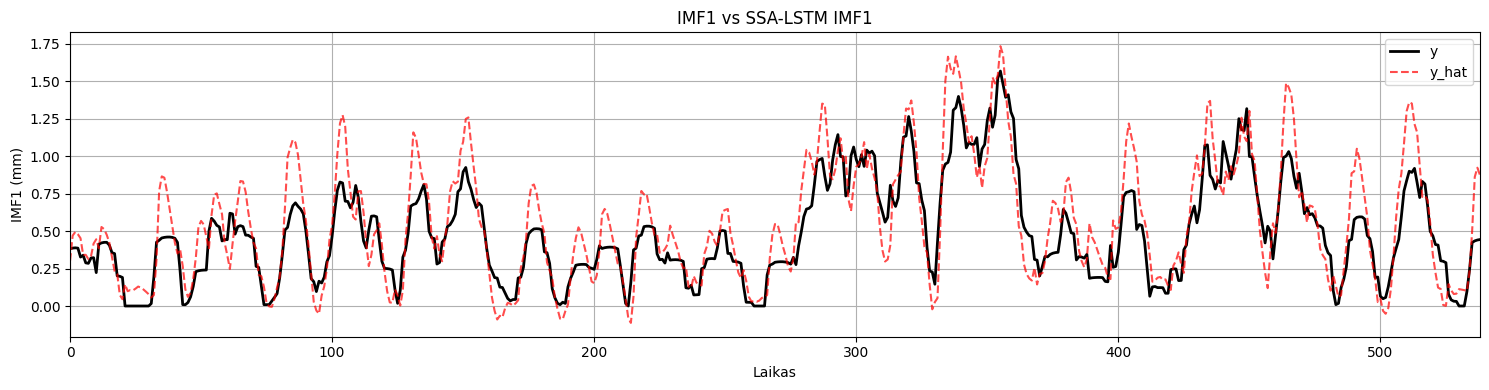

In [201]:
plt.figure(figsize=(15, 4))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF1 vs SSA-LSTM IMF1")
plt.xlabel("Laikas")
plt.ylabel("IMF1 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

R2: 0.9833


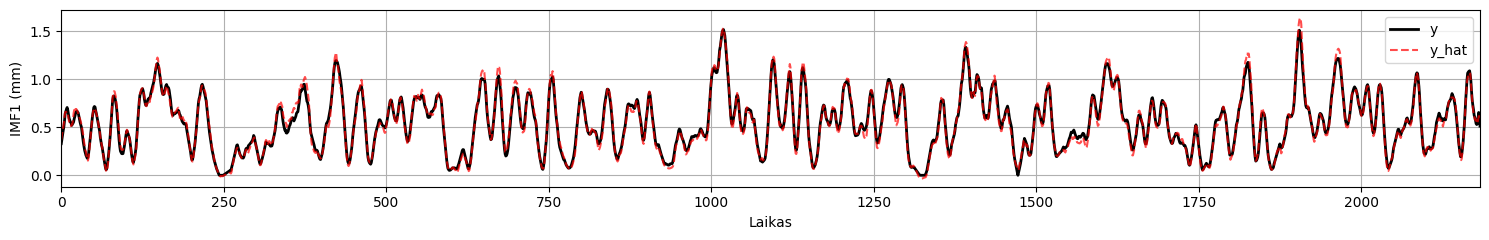

In [202]:
IMF1_fit = pipeline.predict(X_train_IMF1.values)
print(f"R2: {r2_score(y_train['IMF1'][14:], IMF1_fit):.4f}")

plt.figure(figsize=(15, 2.5))
plt.plot(y_train['IMF1'][14:].values, label="y", linewidth=2, color='black')
plt.plot(IMF1_fit, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(IMF1_fit) - 1)
plt.xlabel("Laikas")
plt.ylabel("IMF1 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF2

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 14}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 5}

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 7} R2:       0.3472

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 5}

In [203]:
pipeline = LSTMNet(
    base_module=LSTMRegressor,
    window_size=10,

    module__hidden_dim=128,
    module__num_layers=1,
    module__dropout=0.2,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=20, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=64,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=1.0),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [204]:
pipeline.fit(X_train_IMF2.values, y_train['IMF2'].values)
pred = pipeline.predict(X_test_IMF2.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0074        0.0025     +  0.3143
      2        0.0023        0.0012     +  0.1194
      3        0.0009        0.0006     +  0.1102
      4        0.0005        0.0005     +  0.1191
      5        0.0004        0.0005     +  0.1093
      6        0.0003        0.0004     +  0.1257
      7        0.0003        0.0003     +  0.1253
      8        0.0002        0.0003     +  0.1141
      9        0.0002        0.0003     +  0.1107
     10        0.0002        0.0002     +  0.1179
     11        0.0002        0.0002     +  0.1110
     12        0.0002        0.0002     +  0.1063
     13        0.0002        0.0002     +  0.1166
     14        0.0002        0.0002     +  0.1105
     15        0.0002        0.0002     +  0.1338
     16        0.0002        0.0002     +  0.1112
     17        0.0002        0.0002     +  0.1260
     18        0.0002        0.0002     +  0.1342


In [203]:
param_grid = {
    'window_size': [1, 3, 5],
    'module__hidden_dim': [128],
    'module__num_layers': [1, 2, 3],
    'lr': [0.001],          
    'module__dropout': [0.2, 0.3],
    'batch_size': [32, 64],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF2.values, y_train['IMF2'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF2.values)

Fitting 2 folds for each of 36 candidates, totalling 72 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0122        0.0102     +  0.1202
      2        0.0063        0.0074     +  0.1055
      3        0.0045        0.0060     +  0.1188
      4        0.0037        0.0056     +  0.0958
      5        0.0032        0.0054     +  0.0877
      6        0.0029        0.0053     +  0.0884
      7        0.0027        0.0052     +  0.0931
      8        0.0025        0.0051     +  0.0808
      9        0.0023        0.0050     +  0.0815
     10        0.0021        0.0050     +  0.0777
     11        0.0020        0.0050     +  0.0780
     12        0.0019        0.0050     +  0.0793
     13        0.0017        0.0050        0.0745
     14        0.0016        0.0050        0.0729
     15        0.0016        0.0050        0.0739
     16        0.0015        0.0051        0.0772
     17        0.0014        0.0052    

In [205]:
y_true = y_test['IMF2'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[10:]
y_pred = np.array(pred).reshape(-1)
# y_pred = np.expm1(y_pred)

# Sulygiuojame ilgius
# min_len = min(len(y_true), len(y_pred))
# y_true = y_true[:min_len]
# y_pred = y_pred[:min_len]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF2 = y_true[4:]
y_pred_IMF2 = y_pred[4:]

RMSE:     0.2056
MAE:      0.1561
R2:       0.6175
Spearman: 0.7904


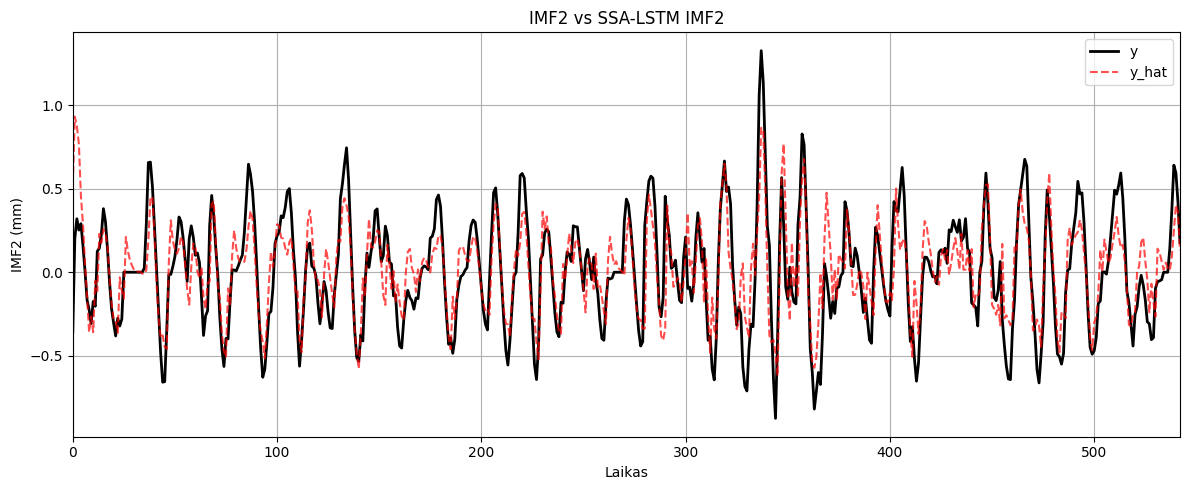

In [207]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF2 vs SSA-LSTM IMF2")
plt.xlabel("Laikas")
plt.ylabel("IMF2 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

R2: 0.9949


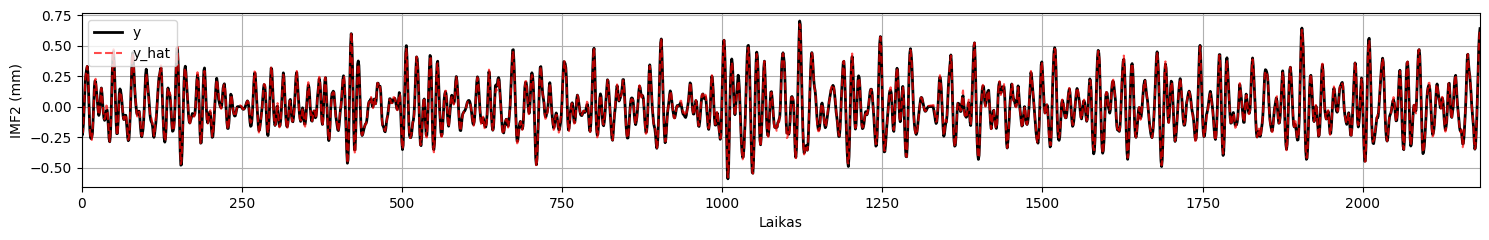

In [208]:
IMF2_fit = pipeline.predict(X_train_IMF2.values)[4:]
print(f"R2: {r2_score(y_train['IMF2'][14:], IMF2_fit):.4f}")

plt.figure(figsize=(15, 2.5))
plt.plot(y_train['IMF2'][14:].values, label="y", linewidth=2, color='black')
plt.plot(IMF2_fit, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(IMF2_fit) - 1)
plt.xlabel("Laikas")
plt.ylabel("IMF2 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF3

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 14}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 5}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.4, 'module__hidden_dim': 256, 'module__num_layers': 1, 'window_size': 3}

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 256, 'module__num_layers': 2, 'window_size': 3}

In [209]:
pipeline = LSTMNet(
    base_module=LSTMRegressor,
    window_size=5,

    module__hidden_dim=256,
    module__num_layers=2,
    module__dropout=0.3,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=10, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=64,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=1.0),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [210]:
pipeline.fit(X_train_IMF3.values, y_train['IMF3_diff'].values)
pred = pipeline.predict(X_test_IMF3.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0035        0.0014     +  0.4015
      2        0.0010        0.0004     +  0.1420
      3        0.0005        0.0003     +  0.1486
      4        0.0004        0.0003        0.1725
      5        0.0003        0.0003     +  0.1556
      6        0.0003        0.0002     +  0.1367
      7        0.0003        0.0002        0.1627
      8        0.0003        0.0003        0.1522
      9        0.0003        0.0002        0.1441
     10        0.0003        0.0002     +  0.1399
     11        0.0002        0.0002     +  0.1430
     12        0.0002        0.0002        0.1485
     13        0.0002        0.0001     +  0.1378
     14        0.0002        0.0001     +  0.1438
     15        0.0002        0.0001        0.1408
     16        0.0002        0.0002        0.1316
     17        0.0002        0.0002        0.1511
     18        0.0002        0.0001        0.1331


In [474]:
param_grid = {
    'window_size': [3, 5],
    'module__hidden_dim': [128, 256],
    'module__num_layers': [1, 2],
    'lr': [0.001],          
    'module__dropout': [0.3, 0.4],
    'batch_size': [32, 64],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF3.values, y_train['IMF3'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF3.values)

Fitting 2 folds for each of 32 candidates, totalling 64 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0181        0.0075     +  0.1272
      2        0.0046        0.0033     +  0.1208
      3        0.0022        0.0027     +  0.1090
      4        0.0016        0.0020     +  0.0959
      5        0.0014        0.0018     +  0.0850
      6        0.0012        0.0018        0.0808
      7        0.0010        0.0018     +  0.0780
      8        0.0010        0.0013     +  0.0749
      9        0.0009        0.0018        0.0801
     10        0.0007        0.0014        0.0770
     11        0.0010        0.0017        0.0779
     12        0.0014        0.0022        0.0770
     13        0.0015        0.0014        0.0858
     14        0.0007        0.0013     +  0.0799
     15        0.0004        0.0010     +  0.0748
     16        0.0002        0.0009     +  0.0774
     17        0.0002        0.0008    

In [211]:
y_true = y_test['IMF3_diff'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[5:]
y_pred = np.array(pred).reshape(-1)
# y_pred = np.expm1(y_pred)

# Sulygiuojame ilgius
# min_len = min(len(y_true), len(y_pred))
# y_true = y_true[:min_len]
# y_pred = y_pred[:min_len]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF3 = y_true[9:]
y_pred_IMF3 = y_pred[9:]

RMSE:     0.1943
MAE:      0.1491
R2:       0.2616
Spearman: 0.4772


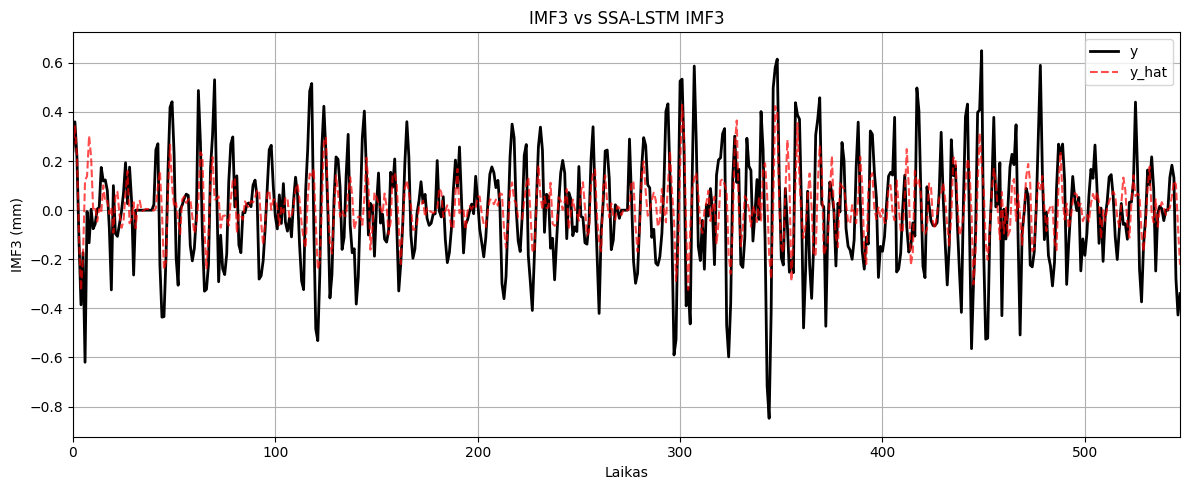

In [212]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF3 vs SSA-LSTM IMF3")
plt.xlabel("Laikas")
plt.ylabel("IMF3 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF4

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 14}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 3}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 256, 'module__num_layers': 1, 'window_size': 3}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 256, 'module__num_layers': 2, 'window_size': 3}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 5}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 5}

32 0.1 128 2 5

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 3}

In [213]:
pipeline = LSTMNet(
    base_module=LSTMFCRegressor,
    window_size=3,

    module__hidden_dim=128,
    module__num_layers=2,
    module__dropout=0.1,
    optimizer__weight_decay = 0,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=12, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.01,
    batch_size=32,
    optimizer=torch.optim.Adam,
    criterion=nn.HuberLoss(delta=1),
    # criterion=nn.L1Loss(),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [214]:
pipeline.fit(X_train_IMF4.values, y_train['IMF4_diff'].values)
pred = pipeline.predict(X_test_IMF4.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0177        0.0160     +  0.5053
      2        0.0117        0.0123     +  0.3460
      3        0.0117        0.0120     +  0.2765
      4        0.0103        0.0086     +  0.2398
      5        0.0118        0.0114        0.2316
      6        0.0112        0.0104        0.2284
      7        0.0072        0.0077     +  0.2262
      8        0.0057        0.0077     +  0.2349
      9        0.0051        0.0067     +  0.2297
     10        0.0056        0.0072        0.2461
     11        0.0047        0.0058     +  0.2429
     12        0.0029        0.0065        0.2359
     13        0.0021        0.0069        0.2316
     14        0.0023        0.0063        0.2333
     15        0.0019        0.0059        0.2437
     16        0.0028        0.0059        0.2599
     17        0.0020        0.0069        0.2589
     18        0.0023        0.0067        0.2487


In [140]:
param_grid = {
    'window_size': [3, 5],
    'module__hidden_dim': [64, 128],
    'module__num_layers': [1, 2],
    'lr': [0.001],          
    'module__dropout': [0.1, 0.2],
    'batch_size': [16, 32],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF4.values, y_train['IMF4_diff'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF4.values)

Fitting 2 folds for each of 32 candidates, totalling 64 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0154        0.0129     +  0.3656
      2        0.0107        0.0123     +  0.2498
      3        0.0119        0.0121     +  0.2100
      4        0.0096        0.0139        0.1943
      5        0.0083        0.0103     +  0.1786
      6        0.0054        0.0104        0.1540
      7        0.0050        0.0159        0.1594
      8        0.0056        0.0107        0.1433
      9        0.0043        0.0088     +  0.1438
     10        0.0027        0.0156        0.1383
     11        0.0043        0.0167        0.1436
     12        0.0047        0.0106        0.1691
     13        0.0026        0.0099        0.1693
     14        0.0025        0.0106        0.1623
     15        0.0040        0.0092        0.1598
     16        0.0019        0.0122        0.1556
     17        0.0021        0.0090    

In [215]:
y_true = y_test['IMF4_diff'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[3:]
y_pred = np.array(pred).reshape(-1)[:]
# y_pred = np.expm1(y_pred)


rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF4 = y_true[11:]
y_pred_IMF4 = y_pred[11:]

RMSE:     0.3013
MAE:      0.2181
R2:       -0.1478
Spearman: 0.1379


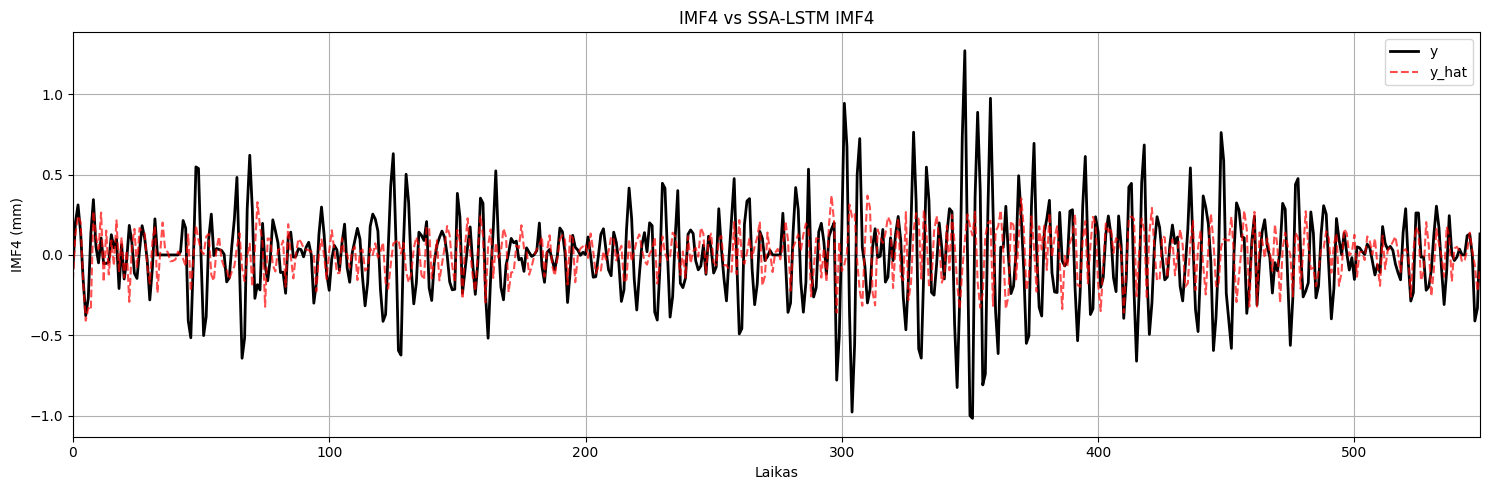

In [216]:
plt.figure(figsize=(15, 5))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF4 vs SSA-LSTM IMF4")
plt.xlabel("Laikas")
plt.ylabel("IMF4 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF5

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 14}

{'batch_size': 16, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 64, 'module__num_layers': 2, 'window_size': 5}

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 2}

In [217]:
pipeline = LSTMNet(
    base_module=LSTMRegressor,
    window_size=2,

    module__hidden_dim=128,
    module__num_layers=2,
    module__dropout=0.3,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=15, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=64,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=1),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [218]:
pipeline.fit(X_train_IMF5.values, y_train['IMF5'].values)
pred = pipeline.predict(X_test_IMF5.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0084        0.0040     +  0.2890
      2        0.0033        0.0013     +  0.1259
      3        0.0013        0.0007     +  0.1276
      4        0.0010        0.0006     +  0.1425
      5        0.0010        0.0007        0.1316
      6        0.0009        0.0006     +  0.1410
      7        0.0008        0.0006     +  0.1414
      8        0.0008        0.0006     +  0.1338
      9        0.0008        0.0006     +  0.1300
     10        0.0008        0.0006        0.1270
     11        0.0008        0.0007        0.1329
     12        0.0007        0.0006        0.1285
     13        0.0007        0.0006     +  0.1379
     14        0.0007        0.0006     +  0.1274
     15        0.0007        0.0006     +  0.1394
     16        0.0007        0.0006        0.1261
     17        0.0007        0.0006        0.1302
     18        0.0007        0.0006        0.1292


In [182]:
param_grid = {
    'window_size': [2, 3, 5],
    'module__hidden_dim': [64, 128],
    'module__num_layers': [1, 2, 3],
    'lr': [0.001, 0.01],          
    'module__dropout': [0.1, 0.2, 0.3],
    'batch_size': [32, 64],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF5.values, y_train['IMF5'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF5.values)

Fitting 2 folds for each of 216 candidates, totalling 432 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0130        0.0087     +  0.0741
      2        0.0045        0.0050     +  0.0646
      3        0.0026        0.0036     +  0.0658
      4        0.0018        0.0028     +  0.0617
      5        0.0013        0.0022     +  0.0636
      6        0.0010        0.0019     +  0.0717
      7        0.0007        0.0016     +  0.0824
      8        0.0006        0.0014     +  0.0679
      9        0.0005        0.0013     +  0.0628
     10        0.0004        0.0012     +  0.0658
     11        0.0003        0.0011     +  0.0681
     12        0.0002        0.0010     +  0.0680
     13        0.0002        0.0009     +  0.0660
     14        0.0002        0.0009     +  0.0654
     15        0.0001        0.0009     +  0.0603
     16        0.0001        0.0008     +  0.0642
     17        0.0001        0.0008  

In [219]:
y_true = y_test['IMF5'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[2:]
y_pred = np.array(pred).reshape(-1)[:]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF5 = y_true[12:]
y_pred_IMF5 = y_pred[12:]

RMSE:     0.2228
MAE:      0.1602
R2:       0.4551
Spearman: 0.6769


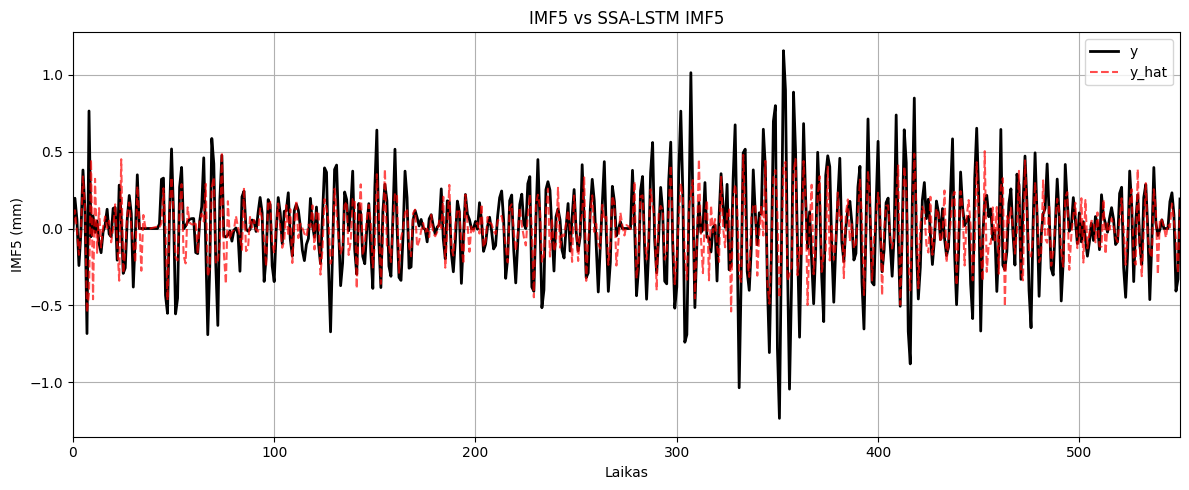

In [220]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF5 vs SSA-LSTM IMF5")
plt.xlabel("Laikas")
plt.ylabel("IMF5 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF6

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 14}

{'batch_size': 16, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 7}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 256, 'module__num_layers': 2, 'window_size': 7}

In [221]:
pipeline = LSTMNet(
    base_module=LSTMFCRegressor,
    window_size=7,

    module__hidden_dim=256,
    module__num_layers=2,
    module__dropout=0.2,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=10, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=32,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=0.5),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [222]:
pipeline.fit(X_train_IMF6.values, y_train['IMF6_diff'].values)
pred = pipeline.predict(X_test_IMF6.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0137        0.0094     +  0.4534
      2        0.0060        0.0038     +  0.3209
      3        0.0036        0.0026     +  0.2978
      4        0.0034        0.0029        0.2717
      5        0.0031        0.0027        0.2712
      6        0.0023        0.0017     +  0.2735
      7        0.0021        0.0017        0.2697
      8        0.0021        0.0016     +  0.2780
      9        0.0018        0.0018        0.3103
     10        0.0021        0.0021        0.2772
     11        0.0022        0.0016     +  0.2784
     12        0.0020        0.0017        0.2665
     13        0.0025        0.0022        0.2753
     14        0.0025        0.0028        0.2720
     15        0.0030        0.0029        0.2822
     16        0.0023        0.0020        0.3369
     17        0.0016        0.0021        0.2996
     18        0.0016        0.0023        0.2889


In [358]:
param_grid = {
    'window_size': [5, 7],
    'module__hidden_dim': [128, 256],
    'module__num_layers': [1, 2],
    'lr': [0.001],          
    'module__dropout': [0.1, 0.2],
    'batch_size': [16, 32],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF6.values, y_train['IMF6'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF6.values)

Fitting 2 folds for each of 32 candidates, totalling 64 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0059        0.0123     +  0.2502
      2        0.0121        0.0113     +  0.2480
      3        0.0045        0.0031     +  0.1873
      4        0.0023        0.0022     +  0.1742
      5        0.0016        0.0018     +  0.1487
      6        0.0009        0.0015     +  0.1461
      7        0.0007        0.0013     +  0.1444
      8        0.0006        0.0012     +  0.1406
      9        0.0005        0.0013        0.1378
     10        0.0004        0.0013        0.1377
     11        0.0004        0.0012     +  0.1375
     12        0.0003        0.0011     +  0.1412
     13        0.0003        0.0017        0.1433
     14        0.0005        0.0027        0.1594
     15        0.0006        0.0013        0.1500
     16        0.0006        0.0027        0.1554
     17        0.0011        0.0021    

In [223]:
y_true = y_test['IMF6_diff'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[7:]
y_pred = np.array(pred).reshape(-1)[:]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF6 = y_true[7:]
y_pred_IMF6 = y_pred[7:]

RMSE:     0.3458
MAE:      0.2609
R2:       0.4665
Spearman: 0.6601


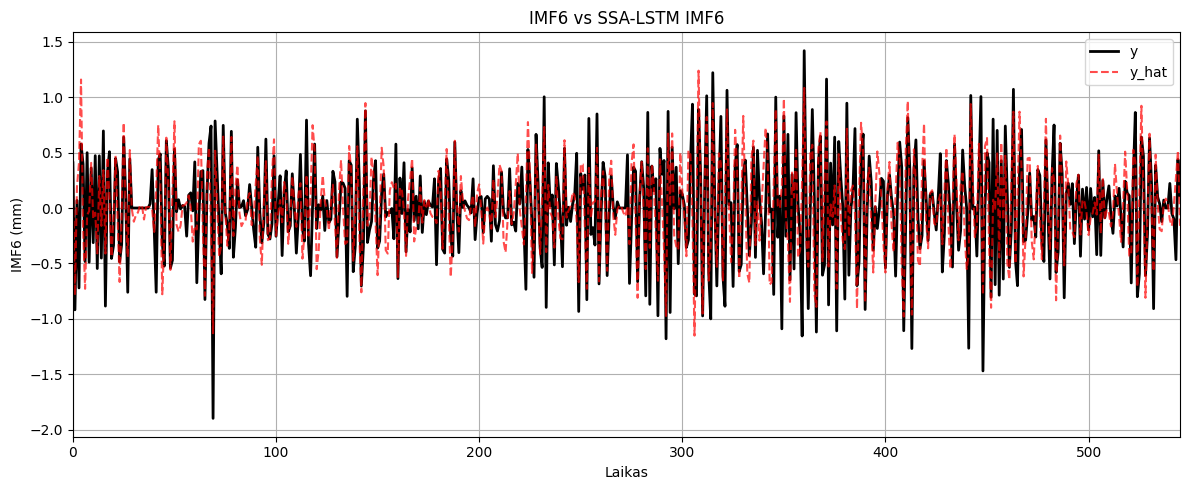

In [224]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF6 vs SSA-LSTM IMF6")
plt.xlabel("Laikas")
plt.ylabel("IMF6 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF7

{'batch_size': 32, 'lr': 0.01, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 14}

 {'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 5}

 {'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 256, 'module__num_layers': 1, 'window_size': 5}

 {'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 256, 'module__num_layers': 1, 'window_size': 5}

 {'batch_size': 32, 'lr': 0.01, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 5} R2:       0.2381

 {'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 4}

 {'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 256, 'module__num_layers': 1, 'window_size': 4}

In [240]:
pipeline = LSTMNet(
    base_module=LSTMFCRegressor,
    window_size=3,

    module__hidden_dim=128,
    module__num_layers=2,
    module__dropout=0.3,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=15, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.01,
    batch_size=32,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=3),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [241]:
pipeline.fit(X_train_IMF7.values, y_train['IMF7'].values)
pred = pipeline.predict(X_test_IMF7.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0115        0.0074     +  0.4417
      2        0.0079        0.0056     +  0.2525
      3        0.0082        0.0075        0.2622
      4        0.0080        0.0059        0.2726
      5        0.0076        0.0046     +  0.2485
      6        0.0055        0.0041     +  0.2370
      7        0.0057        0.0047        0.2254
      8        0.0041        0.0034     +  0.2370
      9        0.0043        0.0035        0.2621
     10        0.0036        0.0037        0.2316
     11        0.0032        0.0035        0.2223
     12        0.0024        0.0033     +  0.2242
     13        0.0024        0.0031     +  0.2287
     14        0.0019        0.0032        0.2280
     15        0.0020        0.0033        0.2280
     16        0.0019        0.0039        0.2327
     17        0.0017        0.0033        0.2421
     18        0.0015        0.0029     +  0.3329


In [240]:
param_grid = {
    'window_size': [4, 5],
    'module__hidden_dim': [128, 256],
    'module__num_layers': [1, 2],
    'lr': [0.001, 0.01],          
    'module__dropout': [0.3],
    'batch_size': [32],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF7.values, y_train['IMF7'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF7.values)

Fitting 2 folds for each of 16 candidates, totalling 32 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0113        0.0082     +  0.1308
      2        0.0075        0.0060     +  0.1317
      3        0.0050        0.0043     +  0.1050
      4        0.0032        0.0032     +  0.0906
      5        0.0020        0.0021     +  0.0887
      6        0.0012        0.0016     +  0.0751
      7        0.0007        0.0012     +  0.0754
      8        0.0005        0.0011     +  0.0733
      9        0.0003        0.0010     +  0.0750
     10        0.0003        0.0010     +  0.0788
     11        0.0002        0.0009     +  0.0777
     12        0.0002        0.0009     +  0.0763
     13        0.0002        0.0009        0.0725
     14        0.0002        0.0009        0.0801
     15        0.0002        0.0010        0.0828
     16        0.0002        0.0009        0.0805
     17        0.0003        0.0009    

In [243]:
y_true = y_test['IMF7'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[3:]
y_pred = np.array(pred).reshape(-1)[:]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF7 = y_true[11:]
y_pred_IMF7 = y_pred[11:]

RMSE:     0.0717
MAE:      0.0539
R2:       -4.3968
Spearman: -0.0410


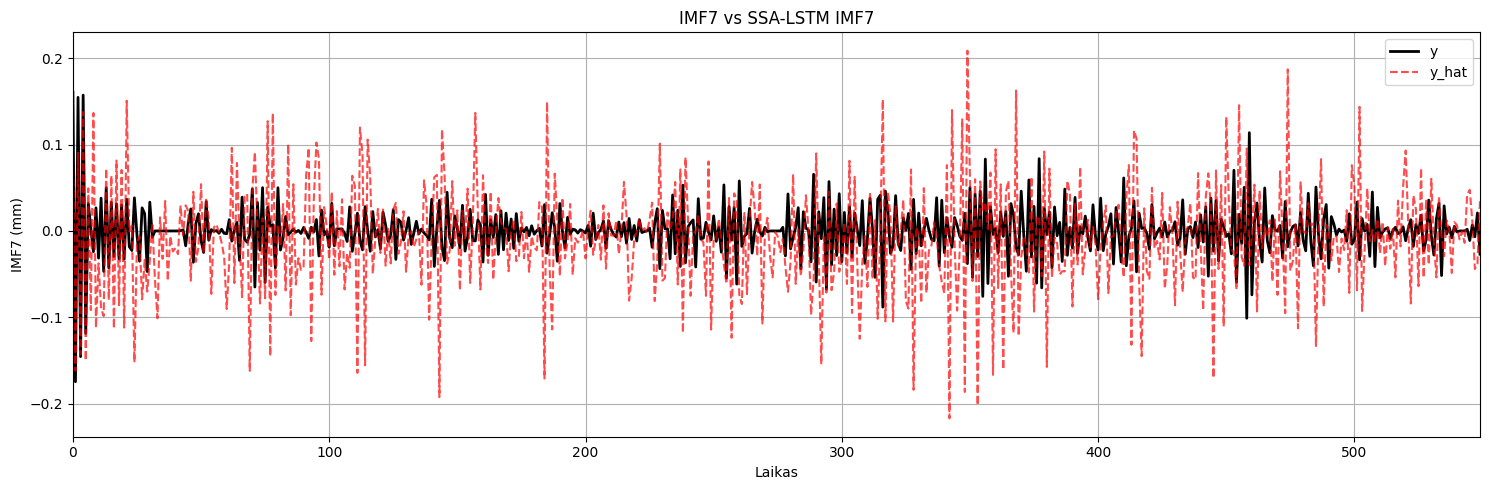

In [244]:
plt.figure(figsize=(15, 5))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF7 vs SSA-LSTM IMF7")
plt.xlabel("Laikas")
plt.ylabel("IMF7 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF8

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 14}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 7}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 256, 'module__num_layers': 2, 'window_size': 7}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 5} R2:       -0.3563

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 5} R2:       -0.1534

In [230]:
pipeline = LSTMNet(
    base_module=LSTMFCRegressor,
    window_size=3,

    module__hidden_dim=128,
    module__num_layers=2,
    module__dropout=0.3,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=15, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=64,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=0.5),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [231]:
pipeline.fit(X_train_IMF8.values, y_train['IMF8'].values)
pred = pipeline.predict(X_test_IMF8.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0441        0.0426     +  0.3887
      2        0.0366        0.0327     +  0.2038
      3        0.0302        0.0282     +  0.1841
      4        0.0269        0.0277     +  0.1389
      5        0.0241        0.0258     +  0.1320
      6        0.0215        0.0248     +  0.1313
      7        0.0200        0.0249        0.1283
      8        0.0189        0.0256        0.1360
      9        0.0185        0.0257        0.1342
     10        0.0189        0.0273        0.1378
     11        0.0172        0.0274        0.1346
     12        0.0155        0.0238     +  0.1327
     13        0.0137        0.0227     +  0.1410
     14        0.0124        0.0215     +  0.1480
     15        0.0115        0.0198     +  0.1423
     16        0.0109        0.0198     +  0.1413
     17        0.0105        0.0202        0.1395
     18        0.0099        0.0204        0.1354


In [178]:
param_grid = {
    'window_size': [5],
    'module__hidden_dim': [64, 128, 256],
    'module__num_layers': [1, 2],
    'lr': [0.001],
    'module__dropout': [0.3],
    'batch_size': [32, 64],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF8.values, y_train['IMF8'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF8.values)

Fitting 2 folds for each of 12 candidates, totalling 24 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0517        0.0452     +  0.2545
      2        0.0478        0.0435     +  0.0888
      3        0.0453        0.0413     +  0.0918
      4        0.0421        0.0385     +  0.0954
      5        0.0380        0.0363     +  0.1027
      6        0.0339        0.0359     +  0.0951
      7        0.0298        0.0328     +  0.1078
      8        0.0242        0.0319     +  0.1037
      9        0.0217        0.0327        0.0957
     10        0.0194        0.0319     +  0.1038
     11        0.0159        0.0313     +  0.1105
     12        0.0130        0.0315        0.1178
     13        0.0111        0.0333        0.1038
     14        0.0096        0.0319        0.1116
     15        0.0074        0.0334        0.1053
     16        0.0063        0.0326        0.1094
     17        0.0047        0.0322    

In [232]:
y_true = y_test['IMF8'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[3:]
y_pred = np.array(pred).reshape(-1)[:]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF8 = y_true[11:]
y_pred_IMF8 = y_pred[11:]

RMSE:     0.3659
MAE:      0.2753
R2:       -0.9186
Spearman: 0.0361


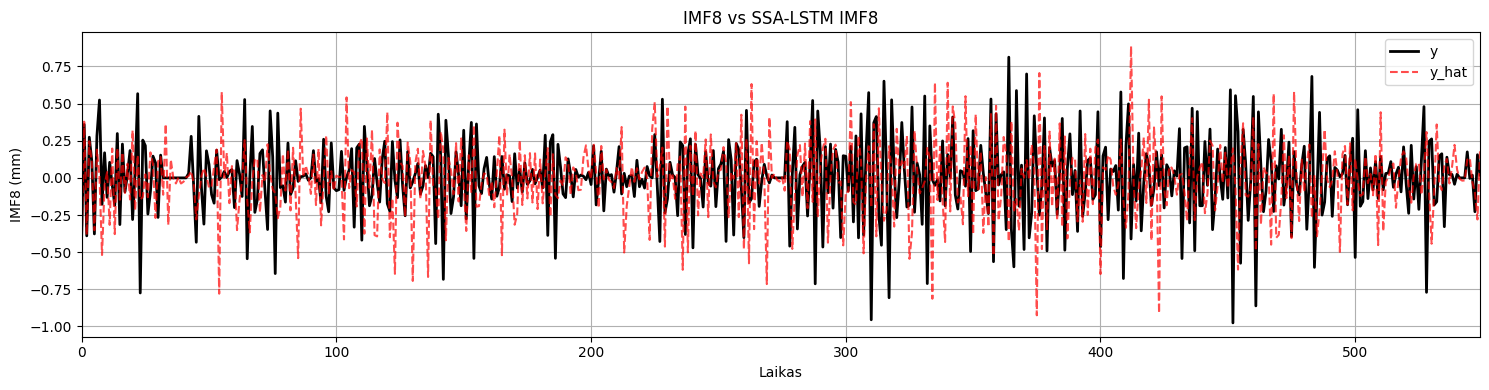

In [233]:
plt.figure(figsize=(15, 4))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF8 vs SSA-LSTM IMF8")
plt.xlabel("Laikas")
plt.ylabel("IMF8 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## SSA-LSTM rezultatai

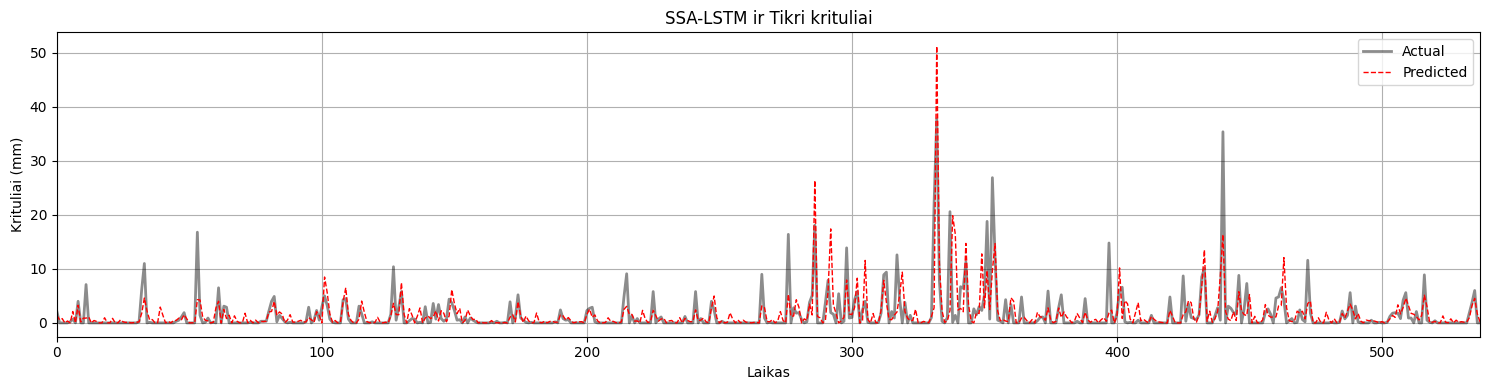

In [246]:
y_pred_IMF3_lvl = X_test_raw['IMF3'].values[14:] + y_pred_IMF3

y_pred_IMF4_lvl = X_test_raw['IMF4'].values[14:] + y_pred_IMF4

y_pred_IMF6_lvl = X_test_raw['IMF6'].values[14:] + y_pred_IMF6

y_true_final = np.expm1(y_original_imf['IMF1'].values.astype(float) + 
                        y_original_imf['IMF2'].values.astype(float) + 
                        y_original_imf['IMF3'].values.astype(float) + 
                        y_original_imf['IMF4'].values.astype(float) + 
                        y_original_imf['IMF5'].values.astype(float) + 
                        y_original_imf['IMF6'].values.astype(float) + 
                        y_original_imf['IMF7'].values.astype(float) + 
                        y_original_imf['IMF8'].values.astype(float))[14:]
y_pred_final = np.expm1(y_pred_IMF1[:] + y_pred_IMF2[:] + y_pred_IMF3_lvl[:] + y_pred_IMF4_lvl[:] + y_pred_IMF5 + y_pred_IMF6_lvl[:] + y_pred_IMF7 + y_pred_IMF8)[:].clip(min=0)
y_actual_precipitation = data['missforest_precipitation'][(int(len(data)*0.8) + 14):-1].values
# y_actual_precipitation = data['missforest_precipitation'][(2017 + 14):-1].values


plt.figure(figsize=(15, 4))
plt.plot(y_actual_precipitation, label="Actual", linewidth=2, alpha=0.45, color = 'black')
# plt.plot(y_true_final, label="True", linewidth=1.2, alpha = 0.8)
plt.plot(y_pred_final, label="Predicted", linewidth=1, alpha=1, color='red', linestyle='--')
plt.xlim(0, len(y_actual_precipitation) - 1)
plt.title("SSA-LSTM ir Tikri krituliai")
plt.xlabel("Laikas")
plt.ylabel("Krituliai (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [247]:
rmse = np.sqrt(mean_squared_error(y_true_final, y_pred_final))
mae  = mean_absolute_error(y_true_final, y_pred_final)
r2   = r2_score(y_true_final, y_pred_final)
spearman_corr, _ = spearmanr(y_true_final, y_pred_final)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

RMSE:     3.0080
MAE:      1.4018
R2:       0.3872
Spearman: 0.4976


In [248]:
rmse = np.sqrt(mean_squared_error(y_actual_precipitation, y_pred_final[:-1]))
mae  = mean_absolute_error(y_actual_precipitation, y_pred_final[:-1])
r2   = r2_score(y_actual_precipitation, y_pred_final[:-1])
spearman_corr, _ = spearmanr(y_actual_precipitation, y_pred_final[:-1])

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

RMSE:     3.0108
MAE:      1.4042
R2:       0.3870
Spearman: 0.6269


In [251]:
data[data['missforest_precipitation']==2.1][['missforest_precipitation', 'observationTime']]

,missforest_precipitation,observationTime
98,2.1,2018-10-07
113,2.1,2018-10-22
174,2.1,2018-12-22
367,2.1,2019-07-03
463,2.1,2019-10-07
834,2.1,2020-10-12
1215,2.1,2021-10-28
1272,2.1,2021-12-24
1492,2.1,2022-08-01
1711,2.1,2023-03-08


In [253]:
results_df = pd.DataFrame({
    'observationTime': observation_times.iloc[(split_idx+14):-1].reset_index(drop=True),
    # 'observationTime': observation_times.iloc[(2017+14):-1].reset_index(drop=True),
    'actual': y_actual_precipitation,
    'SSA-LSTM': y_pred_final[:-1]
})
results_df

# results_df.to_csv('SSA-LSTM_pred.csv')

,observationTime,actual,SSA-LSTM
0,2024-08-11,2.1,1.395520
1,2024-08-12,0.0,0.567791
2,2024-08-13,0.0,0.794638
3,2024-08-14,0.0,0.000000
4,2024-08-15,0.0,0.348558
...,...,...,...
533,2026-01-26,1.9,0.986049
534,2026-01-27,3.8,3.230480
535,2026-01-28,6.0,4.536834
536,2026-01-29,0.0,1.657489
